# Master Thesis
## Beyond Goldfish Memory: What is Relevant in Long-Term Memory?

### Student name: Carmen Ioana Popa
### Student number: 2901935

In [ ]:
# With Python 3.9
# ! pip install -r ../requirements.txt

## Dataset

**ParlAI is a framework for dialogue datasets, it's useful to inspect the datasets but harder to extract the data for bulk data analysis. For this reason, the original MSC datasets were directly downloaded and then processed into CSV format for analysis.**

**Dataset URI: http://parl.ai/downloads/msc/msc_v0.1.tar.gz**

In [ ]:
# Parts of the code were written with the help of Gemini (26-04-2026).

import pandas as pd
import json

# ParlAI is good for looking at the conversations, however, directly processing the dataset files
# is much easier for the analysis.

def create_dataset(base_path, session_ids, dataset_type, output_path):
    """Reads the JSON files for MSC data to create a dataset and save in CSV files.
    """
    session_records = []
    utterance_records = []

    # Iterate through every session.
    for session_id in session_ids:
        file_path = f'{base_path}/session_{session_id}/{dataset_type}.txt'
        with open(file_path, 'r') as f:
            for line in f:
                if not line.strip():
                    continue

                session = json.loads(line)
                # Initial_data_id is the episode_idx.
                initial_data_id = session.get('initial_data_id')

                # init_personas are the seed knowledge given to the annotators.
                init_context = session.get('init_personachat', {})
                init_personas = init_context.get('init_personas', [[], []])
                speaker_1_init = ",".join(init_personas[0])
                speaker_2_init = ",".join(init_personas[1])

                # Extract final personas (gold summary)
                final_personas = init_context.get('personas', [[], []])
                speaker_1_final = ",".join(final_personas[0])
                speaker_2_final = ",".join(final_personas[1])

                # Process the utterances turn by turn.
                extracted_facts = []
                dialog = session.get('dialog', [])

                for turn_idx, turn in enumerate(dialog):
                    speaker = turn.get('id')
                    text = turn.get('text', '')

                    # persona_text is the new fact/memory/summary extracted from this turn/utterance.
                    extracted_persona = turn.get('persona_text', None)

                    # If a fact was extracted this turn, add it to the session summary.
                    if extracted_persona:
                        extracted_facts.append(extracted_persona)

                    utterance_records.append({
                        'initial_data_id': initial_data_id,
                        'session_id': session_id,
                        'turn_index': turn_idx,
                        'speaker': speaker,
                        'text': text,
                        'text_word_count': len(text.split()),
                        'extracted_persona': extracted_persona,
                        'known_personas': turn.get('agg_persona_list', [])
                    })

                # Create session level record.
                session_records.append({
                    'initial_data_id': initial_data_id,
                    'session_id': session_id,
                    'time_elapsed_num': init_context.get('time_num'),
                    'time_elapsed_unit': init_context.get('time_unit'),
                    'total_turns': len(dialog),
                    'speaker_1_init_personas': speaker_1_init,
                    'speaker_2_init_personas': speaker_2_init,
                    'speaker_1_session_summary': speaker_1_final,
                    'speaker_2_session_summary': speaker_2_final,
                    'speaker_1_followup_question': session.get('followup', ''),
                    'speaker_1_new_fact_for_next_session': session.get('newfact', '')
                })

    # Convert to Pandas DataFrames.
    df_sessions = pd.DataFrame(session_records)
    df_utterances = pd.DataFrame(utterance_records)

    # Export to CSV.
    sessions_csv_path = f'{output_path}/{dataset_type}/msc_sessions.csv'
    utterances_csv_path = f'{output_path}/{dataset_type}/msc_utterances.csv'

    df_sessions.to_csv(sessions_csv_path, index=False)
    df_utterances.to_csv(utterances_csv_path, index=False)

    print(f"Saved {len(df_sessions)} session records to '{sessions_csv_path}'")
    print(f"Saved {len(df_utterances)} utterance records to '{utterances_csv_path}'")

In [ ]:
# Download the dataset from http://parl.ai/downloads/msc/msc_v0.1.tar.gz
# and extract the zipped file here in the notebook directory.
base_path = 'msc/msc_personasummary'

create_dataset(base_path, [1, 2, 3], 'train', 'data')
create_dataset(base_path, [1, 2, 3, 4], 'valid', 'data')
create_dataset(base_path, [1, 2, 3, 4], 'test', 'data')

Saved 10285 session records to 'data/train/msc_sessions.csv'
Saved 133290 utterance records to 'data/train/msc_utterances.csv'
Saved 2000 session records to 'data/valid/msc_sessions.csv'
Saved 25459 utterance records to 'data/valid/msc_utterances.csv'
Saved 2004 session records to 'data/test/msc_sessions.csv'
Saved 24375 utterance records to 'data/test/msc_utterances.csv'


## Dataset Exploration and Analysis

### General Statistics

In [ ]:
def print_msc_statistics(df_sessions, df_utterances):
    """
    Computes and prints comprehensive statistics for the MSC dataset.
    """
    # An episode is defined by the initial_data_id (the thread linking sessions together).
    num_episodes = df_sessions['initial_data_id'].nunique()
    num_sessions = len(df_sessions)
    num_utterances = len(df_utterances)
    # Number of summaries per session.
    num_utterances_per_session = df_utterances.groupby('session_id')[['speaker', 'extracted_persona']].count()
    num_utterances_per_session.columns = ['# of utterances', '# of extracted summaries']
    num_empty_summaries = num_utterances_per_session['# of utterances'] - num_utterances_per_session['# of extracted summaries']
    num_empty_summaries.columns = ['# of empty summaries']
    avg_tokens_per_utterance = df_utterances['text_word_count'].mean()

    print(f'Total Unique Episodes in summary dataset: {num_episodes}')
    print(f'Total Sessions in summary dataset (some sessions were dropped from msc dataset): {num_sessions}')
    print(f'Total Turns/Summaries in summary dataset: {num_utterances}\n')
    print(f'Number of utterances/summaries per session: \n{num_utterances_per_session}\n')
    print(f'Number of empty summaries per session: \n{num_empty_summaries}\n')
    print(f'Avg tokens per utterance: {avg_tokens_per_utterance}\n')

    turns_frequency = df_sessions['total_turns'].value_counts().sort_index()

    print(f'Frequency of number of turns: \n{turns_frequency}')
    turns_frequency.plot(kind='bar')

Total Unique Episodes in summary dataset: 4000
Total Sessions in summary dataset (some sessions were dropped from msc dataset): 10285
Total Turns/Summaries in summary dataset: 133290

Number of utterances/summaries per session: 
            # of utterances  # of extracted summaries
session_id                                           
1                     59894                     36370
2                     46420                     29646
3                     26976                     17559

Number of empty summaries per session: 
session_id
1    23524
2    16774
3     9417
dtype: int64

Avg tokens per utterance: 18.093330332358015

Frequency of number of turns: 
total_turns
6        4
7      103
8      130
9      142
10     220
11     101
12    6043
14    1332
16    2113
18      58
20      19
22       4
24       4
26       5
28       2
30       5
Name: count, dtype: int64


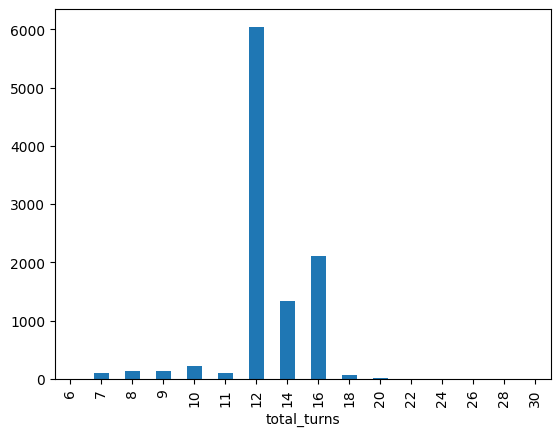

In [ ]:
# Train dataset.
train_dataset_path = 'data/train'
train_sessions_file = f'{train_dataset_path}/msc_sessions.csv'
train_utterances_file = f'{train_dataset_path}/msc_utterances.csv'
train_df_sessions = pd.read_csv(train_sessions_file)
train_df_utterances = pd.read_csv(train_utterances_file)
print_msc_statistics(train_df_sessions, train_df_utterances)

Total Unique Episodes in summary dataset: 500
Total Sessions in summary dataset (some sessions were dropped from msc dataset): 2000
Total Turns/Summaries in summary dataset: 25459

Number of utterances/summaries per session: 
            # of utterances  # of extracted summaries
session_id                                           
1                      7768                      5111
2                      5897                      3808
3                      5890                      3718
4                      5904                      3795

Number of empty summaries per session: 
session_id
1    2657
2    2089
3    2172
4    2109
dtype: int64

Avg tokens per utterance: 20.0234887466122

Frequency of number of turns: 
total_turns
8       36
9       30
10      25
11      25
12    1384
14     138
16     346
18      12
20       3
24       1
Name: count, dtype: int64


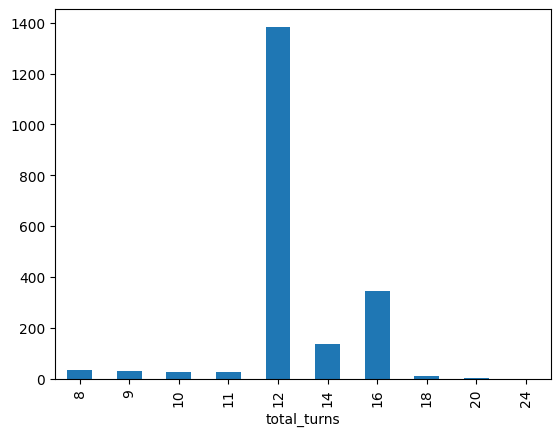

In [ ]:
# Valid dataset.
valid_dataset_path = 'data/valid'
valid_sessions_file = f'{valid_dataset_path}/msc_sessions.csv'
valid_utterances_file = f'{valid_dataset_path}/msc_utterances.csv'
valid_df_sessions = pd.read_csv(valid_sessions_file)
valid_df_utterances = pd.read_csv(valid_utterances_file)
print_msc_statistics(valid_df_sessions, valid_df_utterances)

Total Unique Episodes in summary dataset: 501
Total Sessions in summary dataset (some sessions were dropped from msc dataset): 2004
Total Turns/Summaries in summary dataset: 24375

Number of utterances/summaries per session: 
            # of utterances  # of extracted summaries
session_id                                           
1                      6572                      4658
2                      5939                      3825
3                      5924                      3903
4                      5940                      4011

Number of empty summaries per session: 
session_id
1    1914
2    2114
3    2021
4    1929
dtype: int64

Avg tokens per utterance: 21.00557948717949

Frequency of number of turns: 
total_turns
8       26
9       23
10      26
11       8
12    1653
14     260
16       6
18       1
22       1
Name: count, dtype: int64


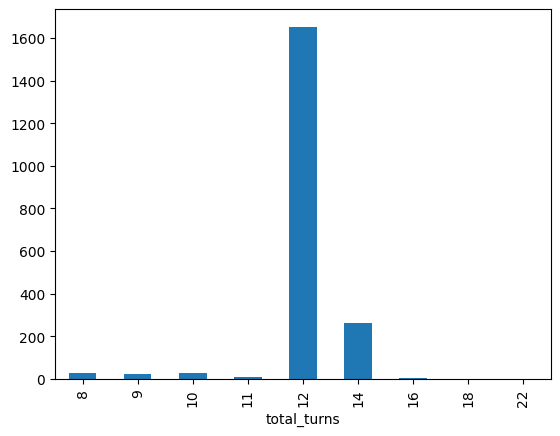

In [ ]:
# Test dataset.
test_dataset_path = 'data/test'
test_sessions_file = f'{test_dataset_path}/msc_sessions.csv'
test_utterances_file = f'{test_dataset_path}/msc_utterances.csv'
test_df_sessions = pd.read_csv(test_sessions_file)
test_df_utterances = pd.read_csv(test_utterances_file)
print_msc_statistics(test_df_sessions, test_df_utterances)

### Macro Statistics

Axes(0.125,0.11;0.775x0.77)
Total unique tokens: 36236


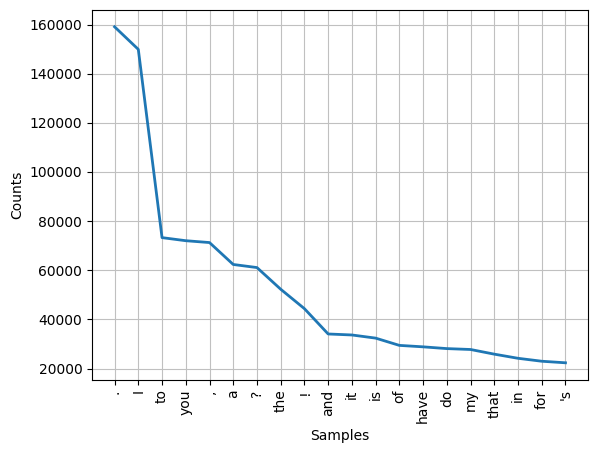

In [ ]:
# Tokenize the conversations.
# Code inspired from the Language as Data course assignments.

import nltk

content = train_df_utterances['text'].str.cat(sep=' ')
tokens = nltk.word_tokenize(content)
fdist = nltk.FreqDist(tokens)
print(fdist.plot(20))

# Total numbers of unique words before stop words and punctuation marks were removed.
unique_tokens = set(tokens)
print(f"Total unique tokens: {len(unique_tokens)}")

[('like', 21681), ('love', 12680), ('good', 10880), ('get', 10575), ('would', 10565), ('really', 9086), ('time', 8653), ('work', 8248), ('great', 7887), ('go', 7711)]

Axes(0.125,0.11;0.775x0.77)


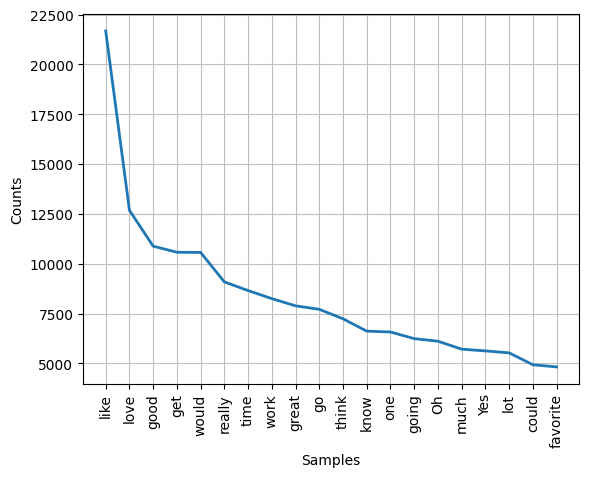

In [ ]:
# Remove the stop words and punctuation marks to can visualise better which are the most frequent words,
# and if it means something for the data.
# Code inspired from the Language as Data course assignments.

stopwords = set(nltk.corpus.stopwords.words("english"))

tokens_filtered = list()
for word in tokens:
    if word.lower() not in stopwords and word.isalpha():
        tokens_filtered.append(word)

fdist_filtered = nltk.FreqDist(tokens_filtered)
print(fdist_filtered.most_common(10))
print()
print(fdist_filtered.plot(20))

In [ ]:
# Code inspired from the Language as Data course assignments.
# Total numbers of unique words after stop words and punctuation marks were removed.

unique_tokens_filtered = set(fdist_filtered)
print(f"Total unique tokens filtered: {len(unique_tokens_filtered)}")

Total unique tokens filtered: 33280


In [ ]:
# Code inspired from the Language as Data course assignments.
# Measure lexical diversity before the stop words and punctuation marks were removed. Before filtered the data
# the token ration was lower, but after filtering the data, the ratio is higher
# This ratio makes sense because punctuation marks were quite frequent before filtering, reducing the lexical diversity of the
# dataset.
Type_token_ratio = len(unique_tokens) / len(tokens)
print ('Type_token_ratio:')
print (Type_token_ratio)

Type_token_ratio:
0.012820177167234745


In [ ]:
# Code inspired from the Language as Data course assignments.
# Measure lexical diversity after the data was filtered. The ratio is higher.
Type_token_ratio_filtered = len(unique_tokens_filtered) / len(tokens_filtered)
print ('Type_token_ratio_filtered:')
print (Type_token_ratio_filtered)

Type_token_ratio_filtered:
0.029965946151338834


<FreqDist with 13651 samples and 757171 outcomes>
Total unique tokens: 13651
[('like', 19230), ('love', 7655), ('work', 5113), ('live', 4628), ('favorite', 3545), ('play', 2571), ('enjoy', 2424), ('go', 2010), ('want', 1914), ('music', 1637)]

Axes(0.125,0.11;0.775x0.77)
Total unique tokens filtered: 8245
summary_Type_token_ratio:
0.018028952508746372
summary_Type_token_ratio_filtered:
0.034991448421034764


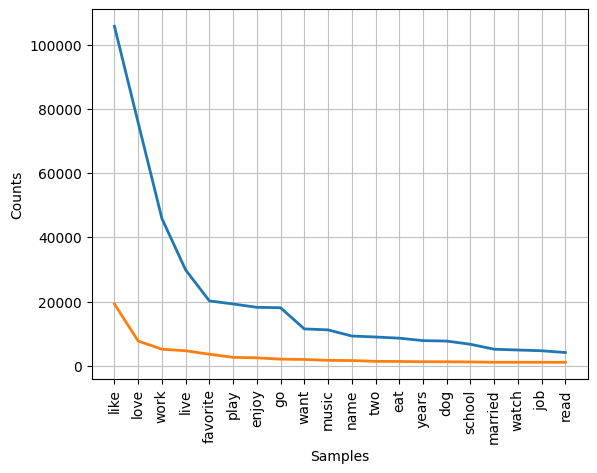

In [ ]:
# Code inspired from the Language as Data course assignments.
# Similarly, for the summary.

df_with_summary = pd.concat([
    train_df_sessions['speaker_1_session_summary'],
    train_df_sessions['speaker_2_session_summary']
])
summaries = df_with_summary.str.cat(sep=' ')
summary_tokens = nltk.word_tokenize(summaries)
summary_fdist = nltk.FreqDist(summary_tokens)
summary_fdist.plot(20)
print(summary_fdist)

summary_unique_tokens = set(summary_tokens)
print(f"Total unique tokens: {len(summary_unique_tokens)}")

stopwords = set(nltk.corpus.stopwords.words("english"))

summary_tokens_filtered = list()
for word in summary_tokens:
    if word.lower() not in stopwords and word.isalpha():
        summary_tokens_filtered.append(word)

summary_fdist_filtered = nltk.FreqDist(summary_tokens_filtered)
print(summary_fdist_filtered.most_common(10))
print()
print(summary_fdist_filtered.plot(20))

summary_unique_tokens_filtered = set(summary_fdist_filtered)
print(f"Total unique tokens filtered: {len(summary_unique_tokens_filtered)}")

summary_Type_token_ratio = len(summary_unique_tokens) / len(summary_tokens)
print ('summary_Type_token_ratio:')
print (summary_Type_token_ratio)

summary_Type_token_ratio_filtered = len(summary_unique_tokens_filtered) / len(summary_tokens_filtered)
print ('summary_Type_token_ratio_filtered:')
print (summary_Type_token_ratio_filtered)

In [ ]:
# Avg utterance length.

avg_utterance_length = train_df_utterances['text_word_count'].mean()

print(f'Average Utterance Length: {avg_utterance_length}')

Average Utterance Length: 18.093330332358015


In [ ]:
# Utterances per episode.

avg_utterance_per_episode = train_df_utterances.groupby('initial_data_id')['text'].count().mean()

print(f'Average Utterances Per Episode: {avg_utterance_per_episode}')

Average Utterances Per Episode: 33.32225


In [ ]:
# Total numbers of sentences in the utterances.

train_df_utterances['num_sentences'] = train_df_utterances['text'].astype(str).map(nltk.sent_tokenize).map(len)

In [ ]:
total_sentences = train_df_utterances['num_sentences'].sum()
sentences_frequency = train_df_utterances['num_sentences'].value_counts().sort_index()

print(f'Total sentences in all utterances: {total_sentences}')
print(f'Frequency of sentences in utterances: \n{sentences_frequency}')

Total sentences in all utterances: 289847
Frequency of sentences in utterances: 
num_sentences
1     40072
2     51322
3     27401
4      9776
5      3235
6      1005
7       322
8        90
9        41
10       17
11        6
12        1
13        1
15        1
Name: count, dtype: int64


In [ ]:
# Measure the average number of tokens per utterance.
# This is higher than the avg token per utterance calculated with text_word_count in dataset
# since word_tokenize considers punctuations as separate tokens.

avg_tokens_per_utterance = len(tokens) / len(train_df_utterances)
print ('Average number of tokens per utterance:')
print (avg_tokens_per_utterance)

Average number of tokens per utterance:
21.205506789706654


In [ ]:
# Measure the average number of tokens per utterance with filtered data.
# This average is lower after filtering because a lot of the punctuation marks and stop words tokens were removed.

average_number_tokens_per_utterance_filtered = len(tokens_filtered) / len(train_df_utterances)
print ('Average number of tokens per utterance after the data was filtered:')
print (average_number_tokens_per_utterance_filtered)

Average number of tokens per utterance after the data was filtered:
8.332162952959711


In [ ]:
# Similarly, for the summary.

# Total numbers of sentences in the summaries.
df_summary_num_sentences = df_with_summary.astype(str).map(nltk.sent_tokenize).map(len)

total_sentences = df_summary_num_sentences.sum()
sentences_frequency = df_summary_num_sentences.value_counts().sort_index()

print(f'Total sentences in all summaries: {total_sentences}')
print(f'Frequency of sentences in summaries: \n{sentences_frequency}')

Total sentences in all summaries: 45753
Frequency of sentences in summaries: 
1     7367
2     6210
3     3882
4     1903
5      782
6      288
7       84
8       29
9        6
10      13
11       6
Name: count, dtype: int64


In [ ]:
# Measure the average number of tokens per summary.
# This is higher than the avg token per utterance calculated with text_word_count in dataset
# since word_tokenize considers punctuations as separate tokens.

num_non_empty_summaries = train_df_utterances['extracted_persona'].count()
average_number_tokens_per_summary = len(summary_tokens) / num_non_empty_summaries
print ('Average number of tokens per summary:')
print (average_number_tokens_per_summary)

# Measure the average number of tokens per summary with filtered data.
# This average is lower after filtering because a lot of the punctuation marks and stop words tokens were removed.

average_number_tokens_per_summary_filtered = len(summary_tokens_filtered) / num_non_empty_summaries
print ('Average number of tokens per summary after the data was filtered:')
print (average_number_tokens_per_summary_filtered)

Average number of tokens per summary:
9.05977864193838
Average number of tokens per summary after the data was filtered:
2.8193718217170205


In [ ]:
# Function vs content words

pos_tagging = nltk.pos_tag(tokens)
print(pos_tagging[:30])

[('I', 'PRP'), ('need', 'VBP'), ('some', 'DT'), ('advice', 'NN'), ('on', 'IN'), ('where', 'WRB'), ('to', 'TO'), ('go', 'VB'), ('on', 'IN'), ('vacation', 'NN'), (',', ','), ('have', 'VBP'), ('you', 'PRP'), ('been', 'VBN'), ('anywhere', 'RB'), ('lately', 'RB'), ('?', '.'), ('I', 'PRP'), ('have', 'VBP'), ('been', 'VBN'), ('all', 'DT'), ('over', 'IN'), ('the', 'DT'), ('world', 'NN'), ('.', '.'), ('I', 'PRP'), ("'m", 'VBP'), ('military', 'JJ'), ('.', '.'), ('That', 'DT')]


In [ ]:
# References:
# https://webapps.towson.edu/ows/ptsspch.htm
# https://tfcs.baruch.cuny.edu/content-and-function-words/

# Based on the reading, I mapped the POS categories to content and function words
# Content Words: {'NN', 'NNS', 'NNP', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'JJ', 'JJR', 'JJS', 'RB'}
# Function Words: {'IN', 'DT', 'PRP', 'CC', 'TO', 'MD', 'WDT', 'WRB', 'PRP$', 'UH'}
# This will also remove punctuations, as they don't have a pos category.

content_pos_tags = {'NN', 'NNS', 'NNP', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'JJ', 'JJR', 'JJS', 'RB'}
function_pos_tags = {'IN', 'DT', 'PRP', 'CC', 'TO', 'MD', 'WDT', 'WRB', 'PRP$', 'UH'}
content_words = list()
function_words = list()

for word, pos_tag in pos_tagging:
    if pos_tag in content_pos_tags:
        content_words.append(word)
    elif pos_tag in function_pos_tags:
        function_words.append(word)


print('Content words examples 30:', content_words[:30])
print('Total numbers of content words:', len(content_words))
print()
print('Function words examples 30:', function_words[:30])
print('Total numbers of function words:', len(function_words))

Content words examples 30: ['need', 'advice', 'go', 'vacation', 'have', 'been', 'anywhere', 'lately', 'have', 'been', 'world', "'m", 'military', 'is', 'good', 'have', 'alot', 'travel', 'experience', 'Sure', 'do', 'lot', 'experience', 'blowing', 'things', 'Haha', 'Bora', 'bora', 'is', 'nice']
Total numbers of content words: 1392030

Function words examples 30: ['I', 'some', 'on', 'where', 'to', 'on', 'you', 'I', 'all', 'over', 'the', 'I', 'That', 'you', 'of', 'And', 'a', 'of', 'I', 'and', 'a', 'The', 'with', 'you', 'before', 'and', 'I', 'at', 'the', 'if']
Total numbers of function words: 1026107


In [ ]:
# Similarly, for the summary.

# Function vs content words

summary_pos_tagging = nltk.pos_tag(summary_tokens)
print(summary_pos_tagging[:30])

content_pos_tags = {'NN', 'NNS', 'NNP', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'JJ', 'JJR', 'JJS', 'RB'}
function_pos_tags = {'IN', 'DT', 'PRP', 'CC', 'TO', 'MD', 'WDT', 'WRB', 'PRP$', 'UH'}
summary_content_words = list()
summary_function_words = list()

for word, pos_tag in summary_pos_tagging:
    if pos_tag in content_pos_tags:
        summary_content_words.append(word)
    elif pos_tag in function_pos_tags:
        summary_function_words.append(word)


print('Content words examples 30:', summary_content_words[:30])
print('Total numbers of content words:', len(summary_content_words))
print()
print('Function words examples 30:', summary_function_words[:30])
print('Total numbers of function words:', len(summary_function_words))

[('I', 'PRP'), ("'ve", 'VBP'), ('been', 'VBN'), ('working', 'VBG'), ('a', 'DT'), ('lot', 'NN'), ('of', 'IN'), ('extra', 'JJ'), ('hours', 'NNS'), ('.', '.'), ('I', 'PRP'), ('want', 'VBP'), ('to', 'TO'), ('break', 'VB'), ('from', 'IN'), ('my', 'PRP$'), ('non-stop', 'JJ'), ('work.', 'NN'), (',', ','), ('I', 'PRP'), ('like', 'VBP'), ('going', 'VBG'), ('to', 'TO'), ('the', 'DT'), ('beach.', 'NN'), (',', ','), ('I', 'PRP'), ('love', 'VBP'), ('brownies', 'NNS'), ('.', '.')]
Content words examples 30: ["'ve", 'been', 'working', 'lot', 'extra', 'hours', 'want', 'break', 'non-stop', 'work.', 'like', 'going', 'beach.', 'love', 'brownies', 'have', 'dogs.', 'play', 'drums.', 'do', "n't", 'like', 'work', 'out.', 'have', 'problem', 'blood', 'sugar.', 'need', 'take']
Total numbers of content words: 384533

Function words examples 30: ['I', 'a', 'of', 'I', 'to', 'from', 'my', 'I', 'to', 'the', 'I', 'I', 'I', 'the', 'I', 'to', 'I', 'a', 'with', 'my', 'I', 'to', 'my', 'I', 'as', 'a', 'I', 'the', 'I', 'my

[('PRP', 333009), ('NN', 297588), ('.', 264574), ('IN', 213123), ('RB', 182220), ('DT', 180772), ('VBP', 176726), ('JJ', 167744), ('VB', 164012), ('NNS', 91913)]

Axes(0.125,0.11;0.775x0.77)


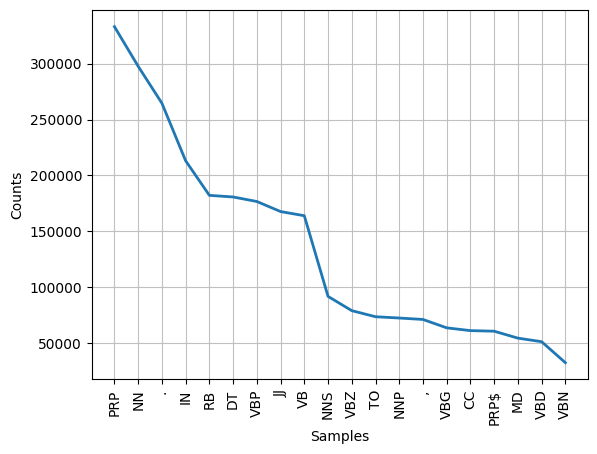

In [ ]:
# Most frequent POS tags
# Dialogue

pos_tags = [pos_tag for word, pos_tag in pos_tagging]
dialogue_pos_fdist = nltk.FreqDist(pos_tags)
print(dialogue_pos_fdist.most_common(10))
print()
print(dialogue_pos_fdist.plot(20))

[('NN', 116162), ('PRP', 108250), ('VBP', 99010), (',', 75801), ('.', 45957), ('DT', 45386), ('IN', 41056), ('JJ', 34934), ('NNP', 29332), ('VB', 22867)]

Axes(0.125,0.11;0.775x0.77)


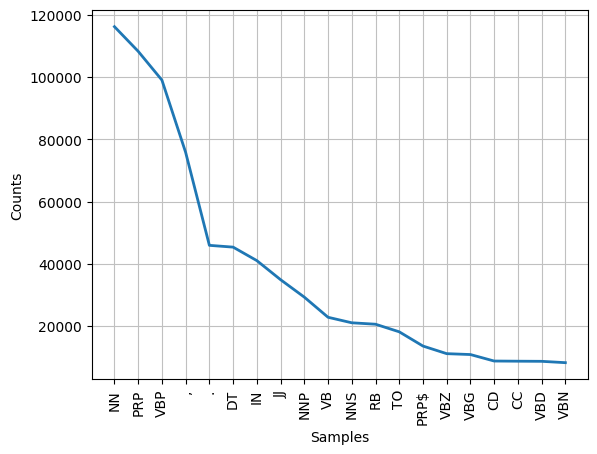

In [ ]:
# Most frequent POS tags
# Summary

summary_pos_tags = [pos_tag for word, pos_tag in summary_pos_tagging]
summary_pos_fdist = nltk.FreqDist(summary_pos_tags)
print(summary_pos_fdist.most_common(10))
print()
print(summary_pos_fdist.plot(20))

## Micro Statistics: Linguistic Cues and Markers

In [ ]:
# Linguistic Cues
# First person, strong emotions and discourse markers.

# Parts of the code was built with Gemini (28-04-2026).

import pandas as pd
import spacy
from spacy.matcher import DependencyMatcher, PhraseMatcher, Matcher
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon', quiet=True)
spacy.cli.download('en_core_web_md')
vader_analyzer = SentimentIntensityAnalyzer()
vader_dict = vader_analyzer.lexicon

nlp = spacy.load("en_core_web_md")

dep_matcher = DependencyMatcher(nlp.vocab)
token_matcher = Matcher(nlp.vocab)

agency_pattern = [
    {"RIGHT_ID": "v", "RIGHT_ATTRS": {"POS": {"IN": ["VERB", "AUX"]}}},
    {
        "LEFT_ID": "v",
        "REL_OP": ">",
        "RIGHT_ID": "subj",
        "RIGHT_ATTRS": {
            "DEP": {"IN": ["nsubj", "nsubjpass", "dobj"]},
            "LOWER": {"IN": ["i", "me", "myself", "we", "us", "ourselves"]}
        }
    }
]
possession_pattern = [
    {"RIGHT_ID": "target_noun", "RIGHT_ATTRS": {"POS": "NOUN"}},
    {
        "LEFT_ID": "target_noun",
        "REL_OP": ">",
        "RIGHT_ID": "poss_pronoun",
        "RIGHT_ATTRS": {
            # Notice we are looking for the 'poss' (possession) dependency!
            "DEP": "poss",
            "LOWER": {"IN": ["my", "mine", "our", "ours"]}
        }
    }
]
dep_matcher.add("FIRST_PERSON_AGENCY", [agency_pattern])
dep_matcher.add("FIRST_PERSON_POSSESSION", [possession_pattern])

discourse_matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
DISCOURSE_LEXICON = [
    # Single word fillers/adverbs
    "actually", "basically", "honestly", "literally", "anyway", "well",

    # Multi-word lexicalized clauses (The ones POS tagging completely misses!)
    "you know", "i mean", "sort of", "kind of", "to be honest", "at the end of the day",

    # Hedging phrases
    "i guess", "i suppose", "pretty much"
]

discourse_patterns = list(nlp.pipe(DISCOURSE_LEXICON))
discourse_matcher.add("DISCOURSE_MARKERS", discourse_patterns)

intj_pattern = [{"POS": "INTJ"}]
token_matcher.add("INTJ_MARKER", [intj_pattern])


def extract_linguistic_features(doc):
    """
    Takes a pre-parsed spaCy Doc object and extracts our linguistic features.
    """
    text = doc.text

    results = {
        'agency_phrase': None,
        'possession_phrase': None,
        'interjection': None,
        'discourse_marker': None,
        'named_entities': None,
        'emotion_polarity': 'neutral',
        'emotion_score': 0.0,
        'emotion_words': None
    }

    # First person and possession.
    agency_phrases = set()
    possession_phrases = set()
    dep_matches = dep_matcher(doc)
    for match_id, token_ids in dep_matches:
        rule_name = nlp.vocab.strings[match_id]

        if rule_name == "FIRST_PERSON_AGENCY":
            # token_ids[0] is the Verb/Aux, token_ids[1] is the Pronoun
            verb = doc[token_ids[0]].text
            pronoun = doc[token_ids[1]].text
            agency_phrases.add(f"{pronoun} {verb}".lower())

        elif rule_name == "FIRST_PERSON_POSSESSION":
            # token_ids[0] is the Target Noun, token_ids[1] is the Pronoun
            noun = doc[token_ids[0]].text
            pronoun = doc[token_ids[1]].text
            possession_phrases.add(f"{pronoun} {noun}".lower())

    if agency_phrases:
        results['agency_phrase'] = ", ".join(list(agency_phrases))
    if possession_phrases:
        results['possession_phrase'] = ", ".join(list(possession_phrases))

    # Interjections.
    intj_matches = token_matcher(doc)
    if intj_matches:
        intj_markers = set()
        for match_id, start, end in intj_matches:
            intj_markers.add(doc[start:end].text.lower())
        results['interjection'] = ", ".join(list(intj_markers))

    # Discourse marker.
    discourse_matches = discourse_matcher(doc)
    if discourse_matches:
        discourse_markers = set()
        for match_id, start, end in discourse_matches:
            # start and end give us the exact token boundaries, even for multi-word phrases
            discourse_markers.add(doc[start:end].text.lower())
        results['discourse_marker'] = ", ".join(list(discourse_markers))

    # Named Entity Recognition (NER)
    if doc.ents:
        # Format as "EntityText (LABEL)" to make it readable.
        # e.g., "New York (GPE), Apple (ORG)"
        # Use dict.fromkeys to remove duplicates but preserve the order they appeared in text
        entities_list = [f"{ent.text} ({ent.label_})" for ent in doc.ents]
        unique_entities = list(dict.fromkeys(entities_list))
        results['named_entities'] = ", ".join(unique_entities)

    # Emotion Scoring (VADER).
    # We score each sentence independently and keep the highest intensity score
    peak_score = 0.0
    for sent in doc.sents:
        score = vader_analyzer.polarity_scores(sent.text)['compound']
        if abs(score) > abs(peak_score):
            peak_score = score

    results['emotion_score'] = peak_score
    if peak_score >= 0.6:
        results['emotion_polarity'] = 'strong_positive'
    elif peak_score <= -0.6:
        results['emotion_polarity'] = 'strong_negative'

    # Emotion Lexical Extraction.
    trigger_words = set()
    for token in doc:
        word = token.text.lower()
        lemma = token.lemma_.lower()
        valence = vader_dict.get(word, vader_dict.get(lemma, 0))

        if abs(valence) >= 1.5:
            trigger_words.add(word)

    if trigger_words:
        results['emotion_words'] = ", ".join(list(trigger_words))

    return results

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.6.0/en_core_web_md-3.6.0-py3-none-any.whl (42.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [ ]:
texts = train_df_utterances['text'].fillna("").astype(str).tolist()
extracted_records = []
doc_generator = nlp.pipe(texts, batch_size=1000, n_process=-1)

for doc in doc_generator:
    features = extract_linguistic_features(doc)
    extracted_records.append(features)

features_df = pd.DataFrame(extracted_records)
train_df_utterances_with_features = pd.concat([train_df_utterances.reset_index(drop=True), features_df.reset_index(drop=True)], axis=1)

output_filename = 'data/train/msc_utterances_linguistic_features.csv'
train_df_utterances_with_features.to_csv(output_filename, index=False)

/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


[(None, 118036), ('well', 6028), ('kind of', 2234), ('actually', 1912), ('you know', 1274), ('i guess', 1007), ('anyway', 283), ('honestly', 259), ('sort of', 248), ('i suppose', 192), ('i mean', 188), ('to be honest', 181), ('well, actually', 158), ('well, you know', 146), ('pretty much', 143), ('basically', 125), ('well, kind of', 99), ('well, i guess', 98), ('literally', 57), ('kind of, actually', 44)]

Axes(0.125,0.11;0.775x0.77)


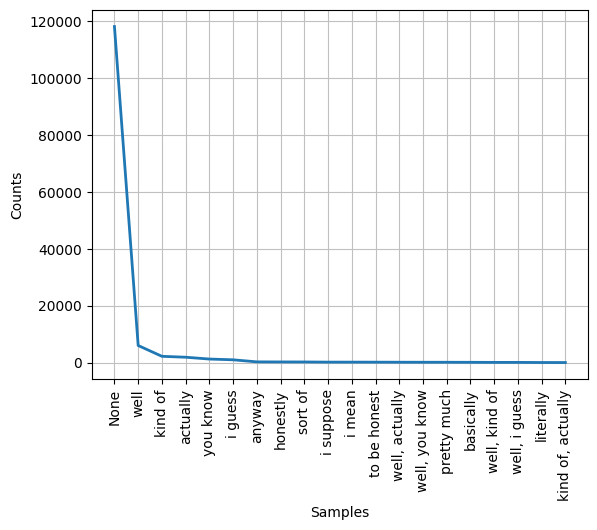

In [ ]:
# Most frequent discourse markers.

train_discourse_markers = train_df_utterances_with_features['discourse_marker']
train_discourse_markers_fdist = nltk.FreqDist(train_discourse_markers)
print(train_discourse_markers_fdist.most_common(20))
print()
print(train_discourse_markers_fdist.plot(20))

[('neutral', 87432), ('strong_positive', 43518), ('strong_negative', 2340)]

Axes(0.125,0.11;0.775x0.77)


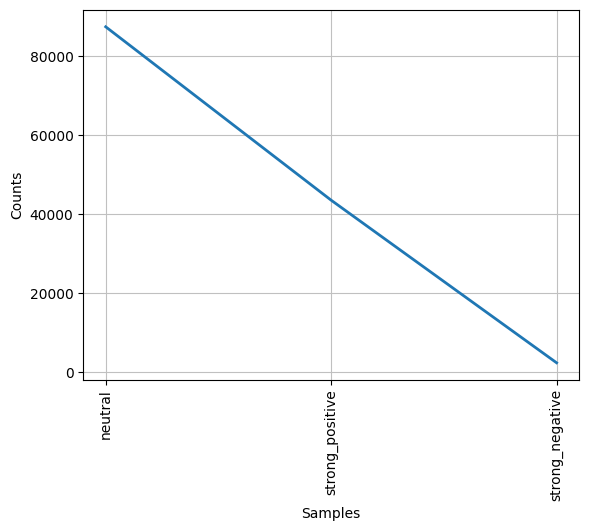

In [ ]:
# Most frequent emotion polarity.

train_emotion_polarity = train_df_utterances_with_features['emotion_polarity']
train_emotion_polarity_fdist = nltk.FreqDist(train_emotion_polarity)
print(train_emotion_polarity_fdist.most_common(20))
print()
print(train_emotion_polarity_fdist.plot(20))

[(None, 96466), ('yes', 5701), ('yeah', 3886), ('oh', 3564), ('no', 2713), ('well', 2303), ('hi', 1847), ('wow', 1772), ('hello', 1504), ('hey', 1046), ('cool', 770), ('like', 518), ('oh, wow', 505), ('lol', 467), ('nice', 465), ('oh, no', 410), ('yea', 401), ('ok', 387), ('sure', 359), ('haha', 344)]

Axes(0.125,0.11;0.775x0.77)


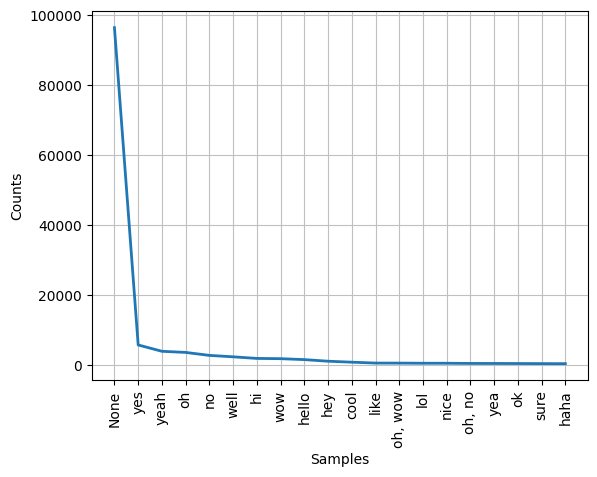

In [ ]:
# Most frequent interjection.

train_interjection = train_df_utterances_with_features['interjection']
train_interjection_fdist = nltk.FreqDist(train_interjection)
print(train_interjection_fdist.most_common(20))
print()
print(train_interjection_fdist.plot(20))

In [ ]:
# How many utterances use possession phrase?

train_df_utterances_with_features['possession_phrase'].isna().map({True: 'None', False: 'Not None'}).value_counts(normalize=True)

possession_phrase
None        0.77594
Not None    0.22406
Name: proportion, dtype: float64

In [ ]:
# How many utterances use agency phrase?

train_df_utterances_with_features['agency_phrase'].isna().map({True: 'None', False: 'Not None'}).value_counts(normalize=True)

agency_phrase
Not None    0.705694
None        0.294306
Name: proportion, dtype: float64

In [ ]:
# Utterances with agency using strong emotions.

train_df_utterances_with_features.dropna(subset=['agency_phrase']).groupby('emotion_polarity')['agency_phrase'].count()

emotion_polarity
neutral            58144
strong_negative     1925
strong_positive    33993
Name: agency_phrase, dtype: int64

In [ ]:
# How many utterances have named entities?

train_df_utterances_with_features['named_entities'].isna().map({True: 'None', False: 'Not None'}).value_counts(normalize=True)

named_entities
None        0.667192
Not None    0.332808
Name: proportion, dtype: float64

<Axes: >

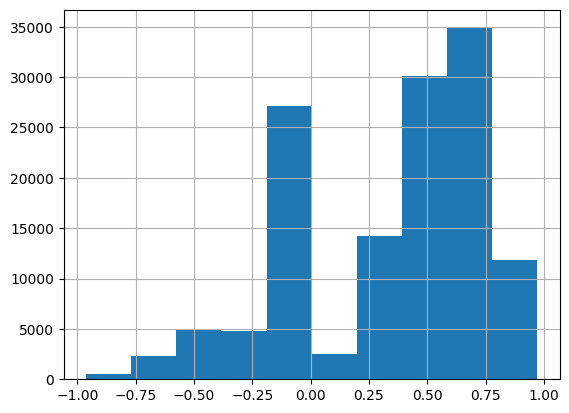

In [ ]:
# Emotion score histogram.

train_df_utterances_with_features['emotion_score'].hist()

<Axes: >

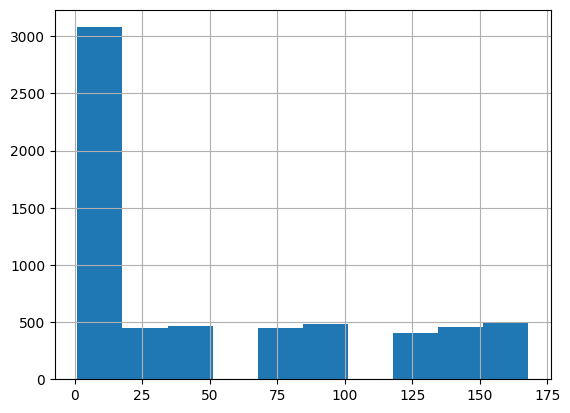

In [ ]:
# time between sessions.

df_multi_session = train_df_sessions[train_df_sessions['session_id'] > 1]
time_strings = df_multi_session['time_elapsed_num'].astype(str) + " " + df_multi_session['time_elapsed_unit']
pd.to_timedelta(time_strings).dt.total_seconds().div(3600).hist()

In [ ]:
# average number of turns in the session based on the time passed between sessions.

time_strings = train_df_sessions['time_elapsed_num'].astype(str) + " " + train_df_sessions['time_elapsed_unit']
train_df_sessions['elapsed_hours'] = pd.to_timedelta(time_strings).dt.total_seconds().div(3600)

train_df_sessions[train_df_sessions['session_id'] > 1].groupby('elapsed_hours')['total_turns'].mean().sort_index(ascending=False)

elapsed_hours
168.0    11.639344
144.0    11.639913
120.0    11.602941
96.0     11.648148
72.0     11.671875
48.0     11.765458
24.0     11.721973
7.0      11.683742
6.0      11.728033
5.0      11.655012
4.0      11.650685
3.0      11.677928
2.0      11.685567
1.0      11.713024
Name: total_turns, dtype: float64

In [ ]:
# Temporal adverbs - then and now
# Parts of the code were created with the help of Gemini (14-05-2026)

from spacy.matcher import Matcher

temporal_matcher = Matcher(nlp.vocab)
temporal_matcher.add("TEMPORAL_NOW", [[{"LOWER": "now", "POS": "ADV"}]])
temporal_matcher.add("TEMPORAL_THEN", [[{"LOWER": "then", "POS": "ADV"}]])

def extract_temporal_adverbs(doc):
    text = doc.text

    results = {
        'has_temporal_then': False,
        'has_temporal_now': False,
    }

    # We also want to exclude the idiom "now and then"
    # A quick check ensures we aren't extracting the idiom
    phrase_text = doc.text.lower()
    if "now and then" in phrase_text or "now and again" in phrase_text:
        return results

    matches = temporal_matcher(doc)
    for match_id, start, end in matches:
        rule_name = nlp.vocab.strings[match_id]
        token = doc[start]

        # Skip then and now at sentence start.
        if token.is_sent_start:
            continue

        # temporal adverbs like then/now always modifies an action or state.
        if token.dep_ != 'intj' and token.head.pos_ in ["VERB", "AUX"]:
            # "Then" must attach to Past Tense (VBD) or Past Participle (VBN).
            if rule_name == "TEMPORAL_THEN" and token.head.tag_ in ["VBD", "VBN"]:
                results['has_temporal_then'] = True
            # "Now" must attach to Present Tense (VBP, VBZ) or Present Participle (VBG).
            elif rule_name == "TEMPORAL_NOW" and token.head.tag_ in ["VBP", "VBZ", "VBG"]:
                results['has_temporal_now'] = True

    return results

In [ ]:
texts = train_df_utterances['text'].fillna("").astype(str).tolist()
extracted_records = []
doc_generator = nlp.pipe(texts, batch_size=1000, n_process=-1)

for doc in doc_generator:
    features = extract_temporal_adverbs(doc)
    extracted_records.append(features)

features_df = pd.DataFrame(extracted_records)
train_df_utterances_with_all_features = pd.concat([train_df_utterances_with_features.reset_index(drop=True), features_df.reset_index(drop=True)], axis=1)

output_filename = 'data/train/msc_utterances_all_linguistic_features.csv'
train_df_utterances_with_all_features.to_csv(output_filename, index=False)

/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
# Number of utterances where the temporal then appears.
train_df_utterances_with_all_features['has_temporal_then'].sum()

256

In [ ]:
# Number of utterances where the temporal now appears.
train_df_utterances_with_all_features['has_temporal_now'].sum()

2570

In [ ]:
train_df_utterances_with_all_features[train_df_utterances_with_all_features['has_temporal_then'] == True]

,initial_data_id,session_id,turn_index,speaker,text,text_word_count,extracted_persona,known_personas,agency_phrase,possession_phrase,interjection,discourse_marker,named_entities,emotion_polarity,emotion_score,emotion_words,has_temporal_then,has_temporal_now
68,train:ordered_5668,1,10,bot_0,I felt angry about it. But that was then and t...,13,NaN,"['I love to cook.', 'I cook.', 'I have 3 child...",i felt,None,None,None,None,neutral,-0.5106,angry,True,True
2698,train:ordered_5539,1,10,bot_0,Sorry for the delay it disconnected then came ...,9,NaN,"['I have a dog called Toto.', 'My favorite ban...",None,None,sorry,None,None,neutral,-0.3818,None,True,False
3512,train:ordered_6560,1,8,bot_0,"Big dreams, and then I fell in love and priori...",14,I fell in love.,"['I am a guy.', 'I am a baker.', 'I bake cakes...",i fell,None,None,None,None,strong_positive,0.7845,"regrets, dreams, love",True,False
4756,train:ordered_4365,1,12,bot_0,Oh wow. It seems he was quite a strong man then,11,NaN,"['I care about our country.', 'I ran for offic...",None,None,"oh, wow",None,None,neutral,0.5859,"strong, wow",True,False
5814,train:ordered_1531,1,12,bot_0,You might have seen each other around during y...,12,NaN,"['I am pregnant.', 'I am a stay at home mom.',...",None,None,None,None,None,neutral,0.0000,None,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131685,train:ordered_859,3,7,bot_1,"At the adoption centre, I planned to adopt. I ...",33,I met my wife at the adoption centre. I am not...,"['I have been in a relationship for 5 years.',...","i know, i 'm, i getting, i planned, i met",None,None,None,None,neutral,0.2500,"thankfully, lonely",True,False
131712,train:ordered_3977,3,10,bot_0,"I had two cats already, and then a friend's ca...",33,I'm sentimental. I ended up with so many cats ...,"['One escaped through the window screen, but I...","i had, i 'm, i bear, i took",my good,None,None,two (CARDINAL),strong_positive,0.6696,"friend, good",True,False
131875,train:ordered_16,3,5,bot_1,Thank you ! Well... who wouldn't feel like tha...,33,NaN,"['I work out at the gym down the street.', 'I ...",None,None,well,well,None,neutral,-0.5994,"like, thank, die, amazing",True,False
132542,train:ordered_503,3,3,bot_1,Yeah I'm hoping to be able to take in the sigh...,31,I would like to visit Sydney.,['I am making plans to travel to Australia wit...,"i hoping, i going",None,yeah,None,"Syndey (PRODUCT), a couple off years ago (DATE)",strong_positive,0.6124,hoping,True,False


In [ ]:
train_df_utterances_with_all_features[train_df_utterances_with_all_features['has_temporal_now'] == True]

,initial_data_id,session_id,turn_index,speaker,text,text_word_count,extracted_persona,known_personas,agency_phrase,possession_phrase,interjection,discourse_marker,named_entities,emotion_polarity,emotion_score,emotion_words,has_temporal_then,has_temporal_now
68,train:ordered_5668,1,10,bot_0,I felt angry about it. But that was then and t...,13,NaN,"['I love to cook.', 'I cook.', 'I have 3 child...",i felt,None,None,None,None,neutral,-0.5106,angry,True,True
193,train:ordered_6237,1,5,bot_1,"I do too, someday. I am too busy with the new ...",14,I am busy with my job.,"['I love to hike.', 'I live in Pennsylvania.',...","i do, i am",None,None,None,None,neutral,0.0000,None,False,True
314,train:ordered_1443,1,8,bot_0,"Far from here, but I live in ny now because th...",14,I moved to NY to be close to an amazing school.,"['I live in NY.', 'I love fashion.', 'I aspire...",i live,None,None,None,ny (GPE),strong_positive,0.7351,amazing,False,True
378,train:ordered_3235,1,12,bot_0,Oh ok. That makes more sense now.,7,NaN,"['My name is stacy.', 'I am 10 years old.', 'I...",None,None,"oh, ok",None,None,neutral,0.2960,None,False,True
387,train:ordered_7864,1,7,bot_1,"Not right now, since the weather is nice, I li...",12,I like to walk.,"['I work at a fast food restaurant.', 'I do no...",i like,None,None,None,None,strong_positive,0.6486,"like, nice",False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133192,train:ordered_645,3,6,bot_0,"Yea, it's been popular for some time now, I fi...",42,I got the game because so many people were vlo...,"['I like playing my new video game.', 'I like ...",i took,None,yea,None,this week (DATE),neutral,0.4215,popular,False,True
133193,train:ordered_645,3,7,bot_1,"Haha, true, he's probably going to play a lot....",36,I have a little boy. My son was sick last week...,"[""I don't have a lot of gaming experience."", '...",None,my husband,None,None,"last weekend (DATE), this last weeks (DATE)",strong_positive,0.8020,"haha, sick, like, help, true, good",False,True
133194,train:ordered_645,3,8,bot_0,"Ah, I'm sorry to hear he was sick, hope he's o...",41,NaN,"['I like playing my new video game.', 'I like ...","me think, i 'm, i hear, i playing",None,ah,None,"Kid (PERSON), Roblox (PERSON)",neutral,0.2023,"hope, sick",False,True
133240,train:ordered_1750,3,6,bot_0,No one but me at first. I have a thing with sc...,57,I still have the bearded dragon.,"['I had a lot of animals growing up.', 'I have...","i care, i have, i got",my friend,None,None,first (ORDINAL),strong_positive,0.8070,"best, scared, like, care, friend",False,True


In [ ]:
# Negation Pattern on an event or action.
# Parts of the code were created with the help of Gemini (21-05-2026)

from spacy.matcher import DependencyMatcher

dep_matcher = DependencyMatcher(nlp.vocab)
negation_pattern = [
    {"RIGHT_ID": "action_verb", "RIGHT_ATTRS": {"POS": {"IN": ["VERB", "AUX"]}}},
    {
        "LEFT_ID": "action_verb",
        "REL_OP": ">",
        "RIGHT_ID": "negation_particle",
        "RIGHT_ATTRS": {"DEP": "neg"}
    }
]
dep_matcher.add("NEGATED_ACTION", [negation_pattern])

def extract_negation(doc):
    """Extracts the negation patterns using SpaCy."""
    text = doc.text

    results = {
        'negation': None,
    }

    negated_phrases = set()
    dep_matches = dep_matcher(doc)
    for match_id, token_ids in dep_matches:
        rule_name = nlp.vocab.strings[match_id]
        if rule_name == "NEGATED_ACTION":
            # token_ids[0] is the Verb/Aux, token_ids[1] is the Negation Particle
            verb = doc[token_ids[0]].text
            neg_particle = doc[token_ids[1]].text
            negated_phrases.add(neg_particle.lower())

    if negated_phrases:
        results['negation'] = ",".join(list(negated_phrases))

    return results

In [ ]:
# Train dataset.
train_dataset_path = 'data/train'
train_features_file = f'{train_dataset_path}/msc_utterances_all_linguistic_features.csv'
train_df_features = pd.read_csv(train_features_file)

In [ ]:
texts = train_df_features['text'].fillna("").astype(str).tolist()
extracted_records = []
doc_generator = nlp.pipe(texts, batch_size=1000, n_process=-1)

for doc in doc_generator:
    features = extract_negation(doc)
    extracted_records.append(features)

features_df = pd.DataFrame(extracted_records)
train_df_features_final = pd.concat([train_df_features.reset_index(drop=True), features_df.reset_index(drop=True)], axis=1)

output_filename = 'data/train/msc_utterances_all_linguistic_features_final.csv'
train_df_features_final.to_csv(output_filename, index=False)

/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
# Total negations
neg_utterances = train_df_features_final['negation'].count()
print('Number of utterances with negation:', neg_utterances)
print('Proportion of utterances with negation:', neg_utterances / len(train_df_features_final))

Number of utterances with negation: 24326
Proportion of utterances with negation: 0.18250431390201816


[("n't", 13442), ('not', 8987), ('never', 2897), ('nt', 634), ('no', 9), ('nope', 1)]


<Axes: xlabel='Samples', ylabel='Counts'>

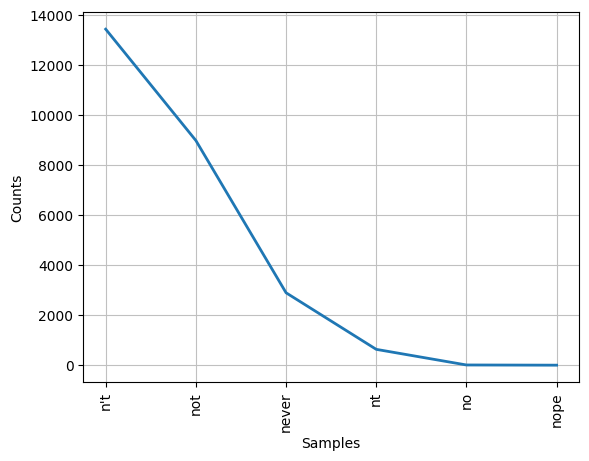

In [ ]:
neg_words = (
    train_df_features_final['negation']
    .dropna()
    .str.split(',')
    .explode()
    .str.strip()
)
negation_freq = nltk.FreqDist(neg_words)
print(negation_freq.most_common(10))
negation_freq.plot(10)

In [ ]:
neg_words_proportions = neg_words.value_counts(normalize=True) * 100

print("Top 10 negation word by percentage:")
print(neg_words_proportions.head(10))

Top 10 negation word by percentage:
negation
n't      51.759723
not      34.605314
never    11.155179
nt        2.441278
no        0.034655
nope      0.003851
Name: proportion, dtype: float64


In [ ]:
# Temporal expressions.
# Parts of the code were created with the help of Gemini (22-05-2026)

from spacy.matcher import Matcher

temporal_matcher = Matcher(nlp.vocab)

# Define the Deictic Adverbs
past_patterns = [
    [{"LOWER": "then"}], [{"LOWER": "previously"}],
    [{"LOWER": "formerly"}], [{"LOWER": "once"}], [{"LOWER": "used"}, {"LOWER": "to"}]
]

recency_patterns = [
    [{"LOWER": "now"}], [{"LOWER": "currently"}],
    [{"LOWER": "presently"}], [{"LOWER": "recently"}], [{"LOWER": "nowadays"}]
]

future_patterns = [
    [{"LOWER": "soon"}], [{"LOWER": "eventually"}],
    [{"LOWER": "later"}], [{"LOWER": "someday"}], [{"LOWER": "tomorrow"}]
]

temporal_matcher.add("STATE_PAST", past_patterns)
temporal_matcher.add("STATE_RECENCY", recency_patterns)
temporal_matcher.add("STATE_FUTURE", future_patterns)

def extract_temporal_state(doc):
    """Extracts the temporal state from the utterances using SpaCy library."""
    matches = temporal_matcher(doc)

    # By default, if no time words are found, we assume the fact is a current reality
    results = {
        'temporal_state': 'STATE_DEFAULT_PRESENT',
        'trigger_word': None
    }

    # Loop through any matches the algorithm found
    for match_id, start, end in matches:
        string_id = nlp.vocab.strings[match_id] # Gets the label (e.g., "STATE_PAST")
        matched_word = doc[start:end].text      # Gets the actual word (e.g., "previously")

        # Overwrite the default dictionary with our findings
        results['temporal_state'] = string_id
        results['trigger_word'] = matched_word

    return results

In [ ]:
texts = train_df_utterances['text'].fillna("").astype(str).tolist()
extracted_records = []
doc_generator = nlp.pipe(texts, batch_size=1000, n_process=-1)

for doc in doc_generator:
    features = extract_temporal_state(doc)
    extracted_records.append(features)

features_df = pd.DataFrame(extracted_records)
train_df_full_features = pd.concat([train_df_features_final.reset_index(drop=True), features_df.reset_index(drop=True)], axis=1)

# Training Dataset used for model training.
output_filename = 'data/train/msc_utterances_full_linguistic_features.csv'
train_df_full_features.to_csv(output_filename, index=False)

/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
print(train_df_full_features['temporal_state'].value_counts())

print(train_df_full_features['temporal_state'].value_counts(normalize=True) * 100)

temporal_state
STATE_DEFAULT_PRESENT    120173
STATE_RECENCY              6108
STATE_PAST                 4380
STATE_FUTURE               2629
Name: count, dtype: int64
temporal_state
STATE_DEFAULT_PRESENT    90.159052
STATE_RECENCY             4.582489
STATE_PAST                3.286068
STATE_FUTURE              1.972391
Name: proportion, dtype: float64


In [ ]:
print(train_df_full_features['trigger_word'].value_counts())

trigger_word
now           4037
then          1930
soon          1411
once          1114
recently      1112
used to        920
currently      462
later          412
Now            343
tomorrow       325
someday        277
Then           242
Once           151
eventually     130
nowadays        71
Currently       47
Someday         24
Recently        23
Soon            15
Tomorrow        15
Used to         12
Eventually      12
previously       9
Later            8
Nowadays         7
presently        4
ONCE             1
NOW              1
Presently        1
Previously       1
Name: count, dtype: int64


In [ ]:
print(train_df_full_features['trigger_word'].value_counts(normalize=True) * 100)

trigger_word
now           30.776854
then          14.713730
soon          10.757033
once           8.492796
recently       8.477548
used to        7.013799
currently      3.522147
later          3.140962
Now            2.614927
tomorrow       2.477701
someday        2.111763
Then           1.844934
Once           1.151178
eventually     0.991080
nowadays       0.541282
Currently      0.358314
Someday        0.182969
Recently       0.175345
Soon           0.114355
Tomorrow       0.114355
Used to        0.091484
Eventually     0.091484
previously     0.068613
Later          0.060990
Nowadays       0.053366
presently      0.030495
ONCE           0.007624
NOW            0.007624
Presently      0.007624
Previously     0.007624
Name: proportion, dtype: float64


In [ ]:
exploded_entities = train_df_full_features['named_entities'].dropna().str.split(',').explode().str.strip()

mask = exploded_entities.str.contains('DATE|TIME', na=False)

entity_counts = exploded_entities[mask].value_counts()

print(entity_counts)
print()
print(exploded_entities[mask].value_counts(normalize=True) * 100)

named_entities
today (DATE)                  2194
tonight (TIME)                 604
this weekend (DATE)            508
one day (DATE)                 483
yesterday (DATE)               325
                              ... 
half hour (TIME)                 1
many late nights (TIME)          1
21st day (DATE)                  1
this past fall (DATE)            1
next this Wednesday (DATE)       1
Name: count, Length: 3418, dtype: int64

named_entities
today (DATE)                  10.695135
tonight (TIME)                 2.944331
this weekend (DATE)            2.476358
one day (DATE)                 2.354490
yesterday (DATE)               1.584284
                                ...    
half hour (TIME)               0.004875
many late nights (TIME)        0.004875
21st day (DATE)                0.004875
this past fall (DATE)          0.004875
next this Wednesday (DATE)     0.004875
Name: proportion, Length: 3418, dtype: float64


### Dialogues changes over the Sessions

Analyze how the dialogue and properties of the conversations chnages over the sessions in an episode.

In [ ]:
import pandas as pd

# Train dataset with all features calculated.
train_dataset_path = 'data/train'
train_features_file = f'{train_dataset_path}/msc_utterances_full_linguistic_features.csv'
train_df_features = pd.read_csv(train_features_file)

In [ ]:
train_df_features.groupby(['initial_data_id', 'session_id']).agg(
    total_turns=('turn_index', 'count'),
    mean_word_count=('text_word_count', 'mean'),
    extracted_facts=('extracted_persona', 'count'),
    negation_rate=('negation', 'count'),
    interjection_count=('interjection', 'count'),
    discourse_marker_count=('discourse_marker', 'count'),
    agency_count=('agency_phrase', 'count'),
    possession_count=('possession_phrase', 'count'),
    strong_emotion_polarity=('emotion_polarity', lambda x: x.isin(['strong_positive', 'strong_negative']).sum()),
    temporal_state_change_count=('temporal_state', lambda x: (x != 'STATE_DEFAULT_PRESENT').sum())
).head(50)

total_turns  mean_word_count  extracted_facts  \
initial_data_id    session_id                                                  
train:ordered_0    1                    14        12.714286               10   
                   2                    12        20.000000                7   
                   3                    12        17.833333                6   
train:ordered_1    1                    14         9.214286               10   
                   2                    10        18.100000                4   
                   3                    12        25.250000                7   
train:ordered_10   1                    14        10.071429               10   
                   2                    10        16.400000                8   
                   3                    12        20.916667                9   
train:ordered_100  1                    14        10.571429                9   
                   2                    12        39.583333               10   
                   3                    12        29.833333                9   
train:ordered_1001 1                    14        11.214286               10   
                   2                    12        20.416667                5   
                   3                    12        43.000000                8   
train:ordered_1002 1                    14         9.857143                6   
                   2                    12        14.250000                8   
                   3                    12        41.416667                8   
train:ordered_1006 1                    16        10.375000                7   
                   2                    12        25.916667                8   
                   3                    12        13.250000               10   
train:ordered_1007 1                    16        11.625000                8   
                   2                    12        26.333333                6   
                   3                    12        23.666667                8   
train:ordered_1008 1                    14         8.928571               10   
                   2                    12        18.833333                9   
                   3                    12        22.666667                5   
train:ordered_1009 1                    14         9.000000                7   
                   2                    12        20.833333                7   
                   3                    12        31.333333                8   
train:ordered_1010 1                    16         9.000000               10   
                   2                     9        19.444444                6   
                   3                    12        32.083333               10   
train:ordered_1013 1                    12        11.416667                9   
                   2                    12        15.583333               10   
                   3                    12        16.833333                7   
train:ordered_1021 1                    16        10.812500               14   
                   2                    12        20.333333                7   
                   3                    12        27.583333                9   
train:ordered_1023 1                    16        10.312500                9   
                   2                    12        17.250000                9   
                   3                    12        32.750000                7   
train:ordered_1024 1                    16        11.375000               11   
                   2                    12        11.416667                8   
                   3                    12        32.416667               10   
train:ordered_1025 1                    16        11.125000               12   
                   2                    12        17.500000                7   
                   3                    10        34.200000                8   
train:ordered_1027 1           

In [ ]:
# Parts of the code created with help of Gemini (27-05-2026)
df_proportions = train_df_features.groupby(['initial_data_id', 'session_id']).agg(
    total_turns=('turn_index', 'count'),
    mean_word_count=('text_word_count', 'mean'),
    extracted_facts=('extracted_persona', 'count'),
    negation_rate=('negation', 'count'),
    interjection_count=('interjection', 'count'),
    discourse_marker_count=('discourse_marker', 'count'),
    agency_count=('agency_phrase', 'count'),
    possession_count=('possession_phrase', 'count'),
    strong_emotion_polarity=('emotion_polarity', lambda x: x.isin(['strong_positive', 'strong_negative']).sum()),
    temporal_state_change_count=('temporal_state', lambda x: (x != 'STATE_DEFAULT_PRESENT').sum())
)

# Define the columns you want to convert into proportions
cols_to_convert = [
    'extracted_facts', 'negation_rate', 'interjection_count',
    'discourse_marker_count', 'agency_count', 'possession_count',
    'strong_emotion_polarity', 'temporal_state_change_count'
]

# Divide each of those columns by the 'total_turns' column
for col in cols_to_convert:
    # Optional: You can rename the columns to reflect they are now proportions
    # prop_col_name = col + '_prop'
    # df_proportions[prop_col_name] = df_proportions[col] / df_proportions['total_turns']

    # Or just overwrite the values in the new dataframe directly:
    df_proportions[col] = df_proportions[col] / df_proportions['total_turns']

# View the new proportions dataframe
df_proportions.head(20)

total_turns  mean_word_count  extracted_facts  \
initial_data_id    session_id                                                  
train:ordered_0    1                    14        12.714286         0.714286   
                   2                    12        20.000000         0.583333   
                   3                    12        17.833333         0.500000   
train:ordered_1    1                    14         9.214286         0.714286   
                   2                    10        18.100000         0.400000   
                   3                    12        25.250000         0.583333   
train:ordered_10   1                    14        10.071429         0.714286   
                   2                    10        16.400000         0.800000   
                   3                    12        20.916667         0.750000   
train:ordered_100  1                    14        10.571429         0.642857   
                   2                    12        39.583333         0.833333   
                   3                    12        29.833333         0.750000   
train:ordered_1001 1                    14        11.214286         0.714286   
                   2                    12        20.416667         0.416667   
                   3                    12        43.000000         0.666667   
train:ordered_1002 1                    14         9.857143         0.428571   
                   2                    12        14.250000         0.666667   
                   3                    12        41.416667         0.666667   
train:ordered_1006 1                    16        10.375000         0.437500   
                   2                    12        25.916667         0.666667   

                               negation_rate  interjection_count  \
initial_data_id    session_id                                      
train:ordered_0    1                0.214286            0.071429   
                   2                0.083333            0.083333   
                   3                0.083333            0.250000   
train:ordered_1    1                0.000000            0.142857   
                   2                0.200000            0.500000   
                   3                0.416667            0.083333   
train:ordered_10   1                0.071429            0.214286   
                   2                0.100000            0.000000   
                   3                0.500000            0.000000   
train:ordered_100  1                0.000000            0.285714   
                   2                0.500000            0.166667   
                   3                0.666667            0.416667   
train:ordered_1001 1                0.285714            0.500000   
                   2                0.250000            0.166667   
                   3                0.416667            0.500000   
train:ordered_1002 1                0.071429            0.357143   
                   2                0.000000            0.250000   
                   3                0.500000            0.083333   
train:ordered_1006 1                0.000000            0.250000   
                   2                0.250000            0.166667   

                               discourse_marker_count  agency_count  \
initial_data_id    session_id                                         
train:ordered_0    1                         0.000000      0.785714   
                   2                         0.083333      0.583333   
                   3                         0.000000      0.583333   
train:ordered_1    1                         0.071429      0.642857   
                   2                         0.200000      0.500000   
                   3                         0.083333      0.750000   
train:ordered_10   1                         0.000000      0.714286   
                   2                         0.000000      0.900000   
                   3                         0.416667      0.83

In [ ]:
# Parts of the code created with help of Gemini (27-05-2026)

# Group by ONLY 'session_id'
overall_session_stats = train_df_features.groupby('session_id').agg(
    total_turns=('turn_index', 'count'),
    mean_word_count=('text_word_count', 'mean'),
    extracted_facts=('extracted_persona', 'count'),
    negation_rate=('negation', 'count'),
    interjection_count=('interjection', 'count'),
    discourse_marker_count=('discourse_marker', 'count'),
    agency_count=('agency_phrase', 'count'),
    possession_count=('possession_phrase', 'count'),
    strong_emotion_polarity=('emotion_polarity', lambda x: x.isin(['strong_positive', 'strong_negative']).sum()),
    temporal_state_change_count=('temporal_state', lambda x: (x != 'STATE_DEFAULT_PRESENT').sum())
)

# Define the columns
cols_to_convert = [
    'extracted_facts', 'negation_rate', 'interjection_count',
    'discourse_marker_count', 'agency_count', 'possession_count',
    'strong_emotion_polarity', 'temporal_state_change_count'
]

# Create a clean dataframe for the percentages
overall_session_percentages = overall_session_stats.copy()

print (overall_session_stats)

# Divide by total turns AND multiply by 100
for col in cols_to_convert:
    overall_session_percentages[col] = (overall_session_percentages[col] / overall_session_percentages['total_turns']) * 100

# View the final percentages
overall_session_percentages

            total_turns  mean_word_count  extracted_facts  negation_rate  \
session_id                                                                 
1                 59894        10.517314            36370           6394   
2                 46420        23.667169            29646          10978   
3                 26976        25.322731            17559           6954   

            interjection_count  discourse_marker_count  agency_count  \
session_id                                                             
1                        16344                    4040         38765   
2                        13083                    6889         34733   
3                         7397                    4325         20564   

            possession_count  strong_emotion_polarity  \
session_id                                              
1                      12343                    14817   
2                      11262                    19291   
3                       6260  

,total_turns,mean_word_count,extracted_facts,negation_rate,interjection_count,discourse_marker_count,agency_count,possession_count,strong_emotion_polarity,temporal_state_change_count
session_id,,,,,,,,,,
1,59894,10.517314,60.723946,10.675527,27.288209,6.745250,64.722677,20.608074,24.738705,5.204194
2,46420,23.667169,63.864713,23.649289,28.183972,14.840586,74.823352,24.261094,41.557518,13.530806
3,26976,25.322731,65.091192,25.778470,27.420670,16.032770,76.230724,23.205813,43.557236,13.786329


## Machine Learning

In [2]:
import pandas as pd
import numpy as np
import os
import json
import spacy
from spacy.matcher import DependencyMatcher, PhraseMatcher, Matcher
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import classification_report

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
# Feature files are loaded or built after the feature-extraction functions are defined.
DATA_DIR = "data"
UTTERANCES_FILENAME = "msc_utterances.csv"
FEATURES_FILENAME = "msc_utterances_full_linguistic_features.csv"

### Data Preparation

In [ ]:
# The helper below will create train_df_features, valid_df_features, and test_df_features.

In [ ]:
# Download NLTK lexicon if needed (quietly)
nltk.download('vader_lexicon', quiet=True)

# Smart Spacy model loading: only download if not already installed
if not spacy.util.is_package("en_core_web_md"):
    spacy.cli.download("en_core_web_md")

nlp = spacy.load("en_core_web_md")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Extract features reuses the features if given from previously saved dataframe, otherwise
# recomputes them. The recomputation logic is important for single inference use for later use.

vader_analyzer = SentimentIntensityAnalyzer()
vader_dict = vader_analyzer.lexicon

# Initialize Matchers
dep_matcher = DependencyMatcher(nlp.vocab)
token_matcher = Matcher(nlp.vocab)
temporal_matcher = Matcher(nlp.vocab)

# First Person Agency Pattern
agency_pattern = [
    {"RIGHT_ID": "v", "RIGHT_ATTRS": {"POS": {"IN": ["VERB", "AUX"]}}},
    {
        "LEFT_ID": "v",
        "REL_OP": ">",
        "RIGHT_ID": "subj",
        "RIGHT_ATTRS": {
            "DEP": {"IN": ["nsubj", "nsubjpass", "dobj"]},
            "LOWER": {"IN": ["i", "me", "myself", "we", "us", "ourselves"]}
        }
    }
]

# First Person Possession Pattern
possession_pattern = [
    {"RIGHT_ID": "target_noun", "RIGHT_ATTRS": {"POS": "NOUN"}},
    {
        "LEFT_ID": "target_noun",
        "REL_OP": ">",
        "RIGHT_ID": "poss_pronoun",
        "RIGHT_ATTRS": {
            "DEP": "poss",
            "LOWER": {"IN": ["my", "mine", "our", "ours"]}
        }
    }
]

negation_pattern = [
    {"RIGHT_ID": "action_verb", "RIGHT_ATTRS": {"POS": {"IN": ["VERB", "AUX"]}}},
    {
        "LEFT_ID": "action_verb",
        "REL_OP": ">",
        "RIGHT_ID": "negation_particle",
        "RIGHT_ATTRS": {"DEP": "neg"}
    }
]

dep_matcher.add("FIRST_PERSON_AGENCY", [agency_pattern])
dep_matcher.add("FIRST_PERSON_POSSESSION", [possession_pattern])
dep_matcher.add("NEGATED_ACTION", [negation_pattern])

# Discourse Markers Pattern
discourse_matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
DISCOURSE_LEXICON = [
    "actually", "basically", "honestly", "literally", "anyway", "well",
    "you know", "i mean", "sort of", "kind of", "to be honest", "at the end of the day",
    "i guess", "i suppose", "pretty much"
]
discourse_patterns = list(nlp.pipe(DISCOURSE_LEXICON))
discourse_matcher.add("DISCOURSE_MARKERS", discourse_patterns)

# Define the Deictic Adverbs
past_patterns = [
    [{"LOWER": "then"}], [{"LOWER": "previously"}],
    [{"LOWER": "formerly"}], [{"LOWER": "once"}], [{"LOWER": "used"}, {"LOWER": "to"}]
]

recency_patterns = [
    [{"LOWER": "now"}], [{"LOWER": "currently"}],
    [{"LOWER": "presently"}], [{"LOWER": "recently"}], [{"LOWER": "nowadays"}]
]

future_patterns = [
    [{"LOWER": "soon"}], [{"LOWER": "eventually"}],
    [{"LOWER": "later"}], [{"LOWER": "someday"}], [{"LOWER": "tomorrow"}]
]
temporal_matcher.add("STATE_PAST", past_patterns)
temporal_matcher.add("STATE_RECENCY", recency_patterns)
temporal_matcher.add("STATE_FUTURE", future_patterns)

# Interjection Pattern
intj_pattern = [{"POS": "INTJ"}]
token_matcher.add("INTJ_MARKER", [intj_pattern])

def extract_features(text, row=None):
    """
    Extracts linguistic cues (agency, possession, interjections, discourse markers, emotion)
    from a given text string.

    If the row is given with existing features - we will use that instead of computing again.
    """
    results = {
        'agency_phrase': None,
        'possession_phrase': None,
        'interjection': None,
        'discourse_marker': None,
        'named_entities': None,
        'negation': None,
        'emotion_polarity': 'neutral',
        'emotion_score': 0.0,
        'emotion_words': None,
        'temporal_state': 'STATE_DEFAULT_PRESENT',
        'trigger_word': None,
    }

    # If the row is given with existing features - we will use that instead of computing again.
    if row is not None:
        for key in results:
            if key in row and not pd.isna(row[key]):
                results[key] = row[key]
        return results

    if pd.isna(text):
        text = ""

    if not text.strip():
        return results

    doc = nlp(str(text))

    agency_phrases = set()
    possession_phrases = set()
    negated_phrases = set()
    dep_matches = dep_matcher(doc)

    for match_id, token_ids in dep_matches:
        rule_name = nlp.vocab.strings[match_id]

        if rule_name == "FIRST_PERSON_AGENCY":
            verb = doc[token_ids[0]].text
            pronoun = doc[token_ids[1]].text
            agency_phrases.add(f"{pronoun} {verb}".lower())

        elif rule_name == "FIRST_PERSON_POSSESSION":
            noun = doc[token_ids[0]].text
            pronoun = doc[token_ids[1]].text
            possession_phrases.add(f"{pronoun} {noun}".lower())

        elif rule_name == "NEGATED_ACTION":
            # token_ids[0] is the Verb/Aux, token_ids[1] is the Negation Particle
            verb = doc[token_ids[0]].text
            neg_particle = doc[token_ids[1]].text
            negated_phrases.add(neg_particle.lower())

    if agency_phrases:
        results['agency_phrase'] = ", ".join(list(agency_phrases))
    if possession_phrases:
        results['possession_phrase'] = ", ".join(list(possession_phrases))
    if negated_phrases:
        results['negation'] = ",".join(list(negated_phrases))

    intj_matches = token_matcher(doc)
    if intj_matches:
        intj_markers = set()
        for match_id, start, end in intj_matches:
            intj_markers.add(doc[start:end].text.lower())
        results['interjection'] = ", ".join(list(intj_markers))

    temporal_matches = temporal_matcher(doc)
    if temporal_matches:
        # Loop through any matches the algorithm found
        for match_id, start, end in temporal_matches:
            string_id = nlp.vocab.strings[match_id] # Gets the label (e.g., "STATE_PAST")
            matched_word = doc[start:end].text      # Gets the actual word (e.g., "previously")

            # Overwrite the default dictionary with our findings
            results['temporal_state'] = string_id
            results['trigger_word'] = matched_word

    discourse_matches = discourse_matcher(doc)
    if discourse_matches:
        discourse_markers = set()
        for match_id, start, end in discourse_matches:
            discourse_markers.add(doc[start:end].text.lower())
        results['discourse_marker'] = ", ".join(list(discourse_markers))

    if doc.ents:
        entities_list = [f"{ent.text} ({ent.label_})" for ent in doc.ents]
        unique_entities = list(dict.fromkeys(entities_list))
        results['named_entities'] = ", ".join(unique_entities)

    peak_score = 0.0
    for sent in doc.sents:
        score = vader_analyzer.polarity_scores(sent.text)['compound']
        if abs(score) > abs(peak_score):
            peak_score = score

    results['emotion_score'] = peak_score
    if peak_score >= 0.6:
        results['emotion_polarity'] = 'strong_positive'
    elif peak_score <= -0.6:
        results['emotion_polarity'] = 'strong_negative'

    trigger_words = set()
    for token in doc:
        word = token.text.lower()
        lemma = token.lemma_.lower()
        valence = vader_dict.get(word, vader_dict.get(lemma, 0))
        if abs(valence) >= 1.5:
            trigger_words.add(word)

    if trigger_words:
        results['emotion_words'] = ", ".join(list(trigger_words))

    return results

In [ ]:
def empty_feature_record():
    return {
        'agency_phrase': None,
        'possession_phrase': None,
        'interjection': None,
        'discourse_marker': None,
        'named_entities': None,
        'negation': None,
        'emotion_polarity': 'neutral',
        'emotion_score': 0.0,
        'emotion_words': None,
        'temporal_state': 'STATE_DEFAULT_PRESENT',
        'trigger_word': None,
    }


def extract_features_from_doc(doc):
    """Extract linguistic features from an already parsed SpaCy Doc."""
    results = empty_feature_record()

    if not doc.text.strip():
        return results

    agency_phrases = set()
    possession_phrases = set()
    negated_phrases = set()
    dep_matches = dep_matcher(doc)

    for match_id, token_ids in dep_matches:
        rule_name = nlp.vocab.strings[match_id]

        if rule_name == "FIRST_PERSON_AGENCY":
            verb = doc[token_ids[0]].text
            pronoun = doc[token_ids[1]].text
            agency_phrases.add(f"{pronoun} {verb}".lower())

        elif rule_name == "FIRST_PERSON_POSSESSION":
            noun = doc[token_ids[0]].text
            pronoun = doc[token_ids[1]].text
            possession_phrases.add(f"{pronoun} {noun}".lower())

        elif rule_name == "NEGATED_ACTION":
            neg_particle = doc[token_ids[1]].text
            negated_phrases.add(neg_particle.lower())

    if agency_phrases:
        results['agency_phrase'] = ", ".join(sorted(agency_phrases))
    if possession_phrases:
        results['possession_phrase'] = ", ".join(sorted(possession_phrases))
    if negated_phrases:
        results['negation'] = ",".join(sorted(negated_phrases))

    intj_matches = token_matcher(doc)
    if intj_matches:
        intj_markers = set()
        for match_id, start, end in intj_matches:
            intj_markers.add(doc[start:end].text.lower())
        results['interjection'] = ", ".join(sorted(intj_markers))

    temporal_matches = temporal_matcher(doc)
    for match_id, start, end in temporal_matches:
        results['temporal_state'] = nlp.vocab.strings[match_id]
        results['trigger_word'] = doc[start:end].text

    discourse_matches = discourse_matcher(doc)
    if discourse_matches:
        discourse_markers = set()
        for match_id, start, end in discourse_matches:
            discourse_markers.add(doc[start:end].text.lower())
        results['discourse_marker'] = ", ".join(sorted(discourse_markers))

    if doc.ents:
        entities_list = [f"{ent.text} ({ent.label_})" for ent in doc.ents]
        unique_entities = list(dict.fromkeys(entities_list))
        results['named_entities'] = ", ".join(unique_entities)

    peak_score = 0.0
    for sent in doc.sents:
        score = vader_analyzer.polarity_scores(sent.text)['compound']
        if abs(score) > abs(peak_score):
            peak_score = score

    results['emotion_score'] = peak_score
    if peak_score >= 0.6:
        results['emotion_polarity'] = 'strong_positive'
    elif peak_score <= -0.6:
        results['emotion_polarity'] = 'strong_negative'

    trigger_words = set()
    for token in doc:
        word = token.text.lower()
        lemma = token.lemma_.lower()
        valence = vader_dict.get(word, vader_dict.get(lemma, 0))
        if abs(valence) >= 1.5:
            trigger_words.add(word)

    if trigger_words:
        results['emotion_words'] = ", ".join(sorted(trigger_words))

    return results


def build_features_for_dataframe(df, text_column="text", batch_size=1000, n_process=-1):
    texts = df[text_column].fillna("").astype(str).tolist()
    extracted_records = []

    doc_generator = nlp.pipe(texts, batch_size=batch_size, n_process=n_process)
    for doc in doc_generator:
        extracted_records.append(extract_features_from_doc(doc))

    features_df = pd.DataFrame(extracted_records)
    feature_columns = list(empty_feature_record().keys())
    df_without_old_features = df.drop(columns=feature_columns, errors="ignore")

    return pd.concat(
        [df_without_old_features.reset_index(drop=True), features_df.reset_index(drop=True)],
        axis=1,
    )


def build_features_for_split(
    split,
    data_dir="data",
    input_filename="msc_utterances.csv",
    output_filename="msc_utterances_full_linguistic_features.csv",
    overwrite=False,
    batch_size=1000,
    n_process=-1,
):
    split_dir = os.path.join(data_dir, split)
    input_path = os.path.join(split_dir, input_filename)
    output_path = os.path.join(split_dir, output_filename)

    if os.path.exists(output_path) and not overwrite:
        return pd.read_csv(output_path)

    df = pd.read_csv(input_path)
    df_features = build_features_for_dataframe(
        df,
        batch_size=batch_size,
        n_process=n_process,
    )
    df_features.to_csv(output_path, index=False)

    return df_features


def build_features_for_splits(splits=("train", "valid", "test"), **kwargs):
    return {split: build_features_for_split(split, **kwargs) for split in splits}


# Build missing split feature files, or load them if they already exist.
split_features = build_features_for_splits(
    data_dir=DATA_DIR,
    input_filename=UTTERANCES_FILENAME,
    output_filename=FEATURES_FILENAME,
)
train_df_features = split_features["train"]
valid_df_features = split_features["valid"]
test_df_features = split_features["test"]


def process_single_utterance(text, scoring_function, row=None):
    features = extract_features(text, row)
    score = scoring_function(features)
    return features, score

### Experiments on Validation Dataset

Train four linear SVM models to classify whether each utterance has a gold persona label.

We will use the features developed above and try Bag of Words and One-Hot vector feature representations.
session id and turn index will be normalized as 3 categories
1. Baseline: Bag of Words of utterance text
2. Binary features: One-hot
3. Categorical features (text based features as n-grams): One-hot

Then train the SVM model on training dataset using the gold label per utterance which classifies the utterance as relevant or not.

We will then use this model to classify each utterance in the validation dataset as relevant or not, and calculate
evaluation metrics against the gold labels.

We will run a few experiments with different hyperparameters, and optionally a feature ablation study.

In [3]:
import os
import pandas as pd
import numpy as np

import joblib
from scipy.sparse import hstack
from sklearn.feature_extraction import DictVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.svm import LinearSVC

TEXT_COLUMN = "text"
GOLD_COLUMN = "extracted_persona"
RANDOM_STATE = 91
MODEL_DIR = "model"

CUE_COLUMNS = [
    "agency_phrase",
    "possession_phrase",
    "interjection",
    "discourse_marker",
    "negation"
]

SUPPLEMENTARY_COLUMNS= [
    "emotion_words",
    "trigger_word"
]

CATEGORICAL_CUE_COLUMNS = [
    "emotion_polarity",
    "temporal_state",
]

In [ ]:
# Parts of the code were created with the help of Codex (29-05-2026)

def add_position_buckets(df):
    session_numbers = pd.to_numeric(df["session_id"], errors="coerce")
    df["session_stage"] = "unknown"
    df.loc[session_numbers == 1, "session_stage"] = "early"
    df.loc[session_numbers == 2, "session_stage"] = "middle"
    df.loc[session_numbers >= 3, "session_stage"] = "late"

    group_columns = ["initial_data_id", "session_id"]
    turn_numbers = pd.to_numeric(df["turn_index"], errors="coerce").fillna(0)
    max_turn_index = turn_numbers.groupby([df[col] for col in group_columns]).transform("max")

    turn_position = turn_numbers / max_turn_index.replace(0, np.nan)
    turn_position = turn_position.fillna(0)
    df["turn_stage"] = "late"
    df.loc[turn_position <= 1/3, "turn_stage"] = "early"
    df.loc[(turn_position > 1/3) & (turn_position <= 2/3), "turn_stage"] = "middle"

    return df


def make_structured_features(df):
    features = pd.DataFrame(index=df.index)
    session_cols = ["session_stage", "turn_stage"]
    for column in CATEGORICAL_CUE_COLUMNS + session_cols:
        features[column] = df[column].fillna("").astype(str)

    for column in CUE_COLUMNS:
        cleaned = df[column].fillna("").astype(str).str.strip()
        features[f"has_{column}"] = cleaned.ne("").astype(int)

    return features.to_dict("records")


def make_cue_text(df):
    return (
        df[CUE_COLUMNS + SUPPLEMENTARY_COLUMNS]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
        .str.strip().fillna("")
    )


def make_gold_labels(df):
    return df[GOLD_COLUMN].fillna("").astype(str).str.strip() != ""


def prepare_data(df):
    df = add_position_buckets(df)

    data = pd.DataFrame(index=df.index)
    data["text"] = df[TEXT_COLUMN].fillna("").astype(str)
    data["cue_text"] = make_cue_text(df)
    data["structured_features"] = make_structured_features(df)
    data["y"] = make_gold_labels(df)

    return data


In [ ]:
# ML Experiments with different features and representations.

EXPERIMENTS = [
    {
        "name": "bow_baseline",
        "use_text": True,
        "use_structured": False,
        "use_cue_text": False,
    },
    {
        "name": "structured_cues",
        "use_text": False,
        "use_structured": True,
        "use_cue_text": False,
    },
    {
        "name": "structured_cues_plus_cue_ngrams",
        "use_text": False,
        "use_structured": True,
        "use_cue_text": True,
    },
    {
        "name": "combined_full_model",
        "use_text": True,
        "use_structured": True,
        "use_cue_text": True,
    },
]

In [4]:
# Model Training

def combine_feature_parts(feature_parts):
    if len(feature_parts) == 1:
        return feature_parts[0]
    return hstack(feature_parts)


def train_model(experiment, train_data):
    feature_parts = []
    vectorizers = {}

    if experiment["use_text"]:
        text_vectorizer = CountVectorizer()
        feature_parts.append(text_vectorizer.fit_transform(train_data["text"]))
        vectorizers["text"] = text_vectorizer

    if experiment["use_structured"]:
        structured_vectorizer = DictVectorizer()
        feature_parts.append(structured_vectorizer.fit_transform(train_data["structured_features"]))
        vectorizers["structured"] = structured_vectorizer

    if experiment["use_cue_text"]:
        cue_vectorizer = CountVectorizer(ngram_range=(1, 4))
        feature_parts.append(cue_vectorizer.fit_transform(train_data["cue_text"]))
        vectorizers["cue_text"] = cue_vectorizer

    X_train = combine_feature_parts(feature_parts)
    model = LinearSVC(random_state=RANDOM_STATE)
    model.fit(X_train, train_data["y"])

    return {
        "name": experiment["name"],
        "experiment": experiment,
        "model": model,
        "vectorizers": vectorizers,
    }

# Save the model for later use.
def save_model(trained_model, output_dir=MODEL_DIR):
    os.makedirs(output_dir, exist_ok=True)

    model_path = os.path.join(output_dir, f"{trained_model['name']}.joblib")
    trained_model["model_path"] = model_path
    joblib.dump(trained_model, model_path)

    return model_path


def load_model(model_path):
    return joblib.load(model_path)


def evaluate_model(model_path, valid_data):
    """Evaluates the model and returns a dictionary of metrics."""
    trained_model = load_model(model_path)
    experiment = trained_model["experiment"]
    vectorizers = trained_model["vectorizers"]
    feature_parts = []

    if experiment["use_text"]:
        feature_parts.append(vectorizers["text"].transform(valid_data["text"]))

    if experiment["use_structured"]:
        feature_parts.append(vectorizers["structured"].transform(valid_data["structured_features"]))

    if experiment["use_cue_text"]:
        feature_parts.append(vectorizers["cue_text"].transform(valid_data["cue_text"]))

    X_valid = combine_feature_parts(feature_parts)
    y_valid = valid_data["y"]
    y_pred = trained_model["model"].predict(X_valid)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_valid,
        y_pred,
        average="macro",
        zero_division=0,
    )

    precision_relevant, recall_relevant, f1_relevant, _ = precision_recall_fscore_support(
        y_valid,
        y_pred,
        average="binary",
        pos_label=True,
        zero_division=0,
    )

    metrics = {
        "model": trained_model["name"],
        "total_rows": len(y_valid),
        "gold_relevant_rows": int(y_valid.sum()),
        "predicted_relevant_rows": int(y_pred.sum()),
        "accuracy": round(accuracy_score(y_valid, y_pred), 3),
        "precision_macro": round(precision, 3),
        "recall_macro": round(recall, 3),
        "f1_macro": round(f1, 3),
        "precision_relevant": round(float(precision_relevant), 3),
        "recall_relevant": round(float(recall_relevant), 3),
        "f1_relevant": round(float(f1_relevant), 3),
        "model_path": model_path,
    }

    print("\n" + "=" * 70)
    print(f"ML EXPERIMENT: {trained_model['name']}")
    print("=" * 70)
    print(classification_report(
        y_valid,
        y_pred,
        labels=[False, True],
        target_names=["not_relevant", "relevant"],
        zero_division=0,
    ))

    return metrics, y_pred, y_valid

In [ ]:
# Prepare the datasets which will be used for training and evaluation.

train_data = prepare_data(train_df_features)
valid_data = prepare_data(valid_df_features)
test_data = prepare_data(test_df_features)

In [ ]:
for experiment in EXPERIMENTS:
    trained_model = train_model(experiment, train_data)
    model_path = save_model(trained_model)

/usr/local/anaconda3/envs/parlai/lib/python3.9/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### Utterance (Turn) Level Binary Evaluation - Validation Dataset

In [ ]:
prediction_context_columns = ["initial_data_id", "session_id", "turn_index", "speaker", TEXT_COLUMN, GOLD_COLUMN]
valid_predictions = valid_df_features[prediction_context_columns]

In [ ]:
# Validation Dataset

results = []

for experiment in EXPERIMENTS:
    model_path = os.path.join(MODEL_DIR, f"{experiment['name']}.joblib")
    metrics, y_pred, y_valid = evaluate_model(model_path, valid_data)

    if "y_true" not in valid_predictions.columns:
        valid_predictions["y_true"] = y_valid.values

    results.append(metrics)
    valid_predictions[f"pred_{experiment['name']}"] = y_pred

os.makedirs("results", exist_ok=True)
valid_predictions.to_csv("results/valid_predictions.csv", index=False)

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False)
results_df


ML EXPERIMENT: bow_baseline
              precision    recall  f1-score   support

not_relevant       0.66      0.69      0.67      9027
    relevant       0.83      0.80      0.81     16432

    accuracy                           0.76     25459
   macro avg       0.74      0.75      0.74     25459
weighted avg       0.77      0.76      0.76     25459



/var/folders/_b/0x2j9g_n5ng84d2k_v0_40h40000gn/T/ipykernel_874/1775605457.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_predictions["y_true"] = y_valid.values
/var/folders/_b/0x2j9g_n5ng84d2k_v0_40h40000gn/T/ipykernel_874/1775605457.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_predictions[f"pred_{experiment['name']}"] = y_pred



ML EXPERIMENT: structured_cues
              precision    recall  f1-score   support

not_relevant       0.75      0.54      0.63      9027
    relevant       0.78      0.90      0.84     16432

    accuracy                           0.77     25459
   macro avg       0.76      0.72      0.73     25459
weighted avg       0.77      0.77      0.76     25459



/var/folders/_b/0x2j9g_n5ng84d2k_v0_40h40000gn/T/ipykernel_874/1775605457.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_predictions[f"pred_{experiment['name']}"] = y_pred



ML EXPERIMENT: structured_cues_plus_cue_ngrams
              precision    recall  f1-score   support

not_relevant       0.66      0.71      0.68      9027
    relevant       0.83      0.80      0.82     16432

    accuracy                           0.77     25459
   macro avg       0.75      0.75      0.75     25459
weighted avg       0.77      0.77      0.77     25459



/var/folders/_b/0x2j9g_n5ng84d2k_v0_40h40000gn/T/ipykernel_874/1775605457.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_predictions[f"pred_{experiment['name']}"] = y_pred



ML EXPERIMENT: combined_full_model
              precision    recall  f1-score   support

not_relevant       0.67      0.73      0.70      9027
    relevant       0.85      0.80      0.82     16432

    accuracy                           0.78     25459
   macro avg       0.76      0.77      0.76     25459
weighted avg       0.78      0.78      0.78     25459



/var/folders/_b/0x2j9g_n5ng84d2k_v0_40h40000gn/T/ipykernel_874/1775605457.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_predictions[f"pred_{experiment['name']}"] = y_pred


,model,total_rows,gold_relevant_rows,predicted_relevant_rows,accuracy,precision_macro,recall_macro,f1_macro,precision_relevant,recall_relevant,f1_relevant,model_path
3,combined_full_model,25459,16432,15534,0.776,0.756,0.766,0.760,0.845,0.799,0.821,model/combined_full_model.joblib
2,structured_cues_plus_cue_ngrams,25459,16432,15796,0.767,0.746,0.753,0.749,0.832,0.800,0.816,model/structured_cues_plus_cue_ngrams.joblib
0,bow_baseline,25459,16432,15900,0.762,0.741,0.747,0.744,0.826,0.800,0.813,model/bow_baseline.joblib
1,structured_cues,25459,16432,18945,0.772,0.764,0.719,0.731,0.780,0.900,0.836,model/structured_cues.joblib


In [ ]:
prediction_context_columns = ["initial_data_id", "session_id", "turn_index", "speaker", TEXT_COLUMN, GOLD_COLUMN]
test_predictions = test_df_features[prediction_context_columns]

### Utterance (Turn) Level Binary Evaluation - Test Dataset

In [ ]:
# Test Dataset

results_test = []

for experiment in EXPERIMENTS:
    model_path = os.path.join(MODEL_DIR, f"{experiment['name']}.joblib")
    metrics, y_pred, y_valid = evaluate_model(model_path, test_data)

    if "y_true" not in test_predictions.columns:
        test_predictions["y_true"] = y_valid.values

    results_test.append(metrics)
    test_predictions[f"pred_{experiment['name']}"] = y_pred

os.makedirs("results", exist_ok=True)
test_predictions.to_csv("results/test_predictions.csv", index=False)

results_df_test = pd.DataFrame(results_test).sort_values("f1_macro", ascending=False)
results_df_test


ML EXPERIMENT: bow_baseline
              precision    recall  f1-score   support

not_relevant       0.63      0.69      0.66      7978
    relevant       0.84      0.80      0.82     16397

    accuracy                           0.77     24375
   macro avg       0.74      0.75      0.74     24375
weighted avg       0.77      0.77      0.77     24375



/var/folders/_b/0x2j9g_n5ng84d2k_v0_40h40000gn/T/ipykernel_874/817906847.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_predictions["y_true"] = y_valid.values
/var/folders/_b/0x2j9g_n5ng84d2k_v0_40h40000gn/T/ipykernel_874/817906847.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_predictions[f"pred_{experiment['name']}"] = y_pred



ML EXPERIMENT: structured_cues
              precision    recall  f1-score   support

not_relevant       0.71      0.54      0.61      7978
    relevant       0.80      0.89      0.84     16397

    accuracy                           0.78     24375
   macro avg       0.76      0.72      0.73     24375
weighted avg       0.77      0.78      0.77     24375



/var/folders/_b/0x2j9g_n5ng84d2k_v0_40h40000gn/T/ipykernel_874/817906847.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_predictions[f"pred_{experiment['name']}"] = y_pred



ML EXPERIMENT: structured_cues_plus_cue_ngrams
              precision    recall  f1-score   support

not_relevant       0.61      0.71      0.66      7978
    relevant       0.85      0.78      0.81     16397

    accuracy                           0.76     24375
   macro avg       0.73      0.75      0.74     24375
weighted avg       0.77      0.76      0.76     24375



/var/folders/_b/0x2j9g_n5ng84d2k_v0_40h40000gn/T/ipykernel_874/817906847.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_predictions[f"pred_{experiment['name']}"] = y_pred



ML EXPERIMENT: combined_full_model
              precision    recall  f1-score   support

not_relevant       0.63      0.73      0.68      7978
    relevant       0.86      0.80      0.83     16397

    accuracy                           0.77     24375
   macro avg       0.75      0.76      0.75     24375
weighted avg       0.78      0.77      0.78     24375



/var/folders/_b/0x2j9g_n5ng84d2k_v0_40h40000gn/T/ipykernel_874/817906847.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_predictions[f"pred_{experiment['name']}"] = y_pred


,model,total_rows,gold_relevant_rows,predicted_relevant_rows,accuracy,precision_macro,recall_macro,f1_macro,precision_relevant,recall_relevant,f1_relevant,model_path
3,combined_full_model,24375,16397,15242,0.773,0.745,0.761,0.751,0.856,0.796,0.825,model/combined_full_model.joblib
0,bow_baseline,24375,16397,15677,0.765,0.735,0.745,0.739,0.840,0.804,0.822,model/bow_baseline.joblib
2,structured_cues_plus_cue_ngrams,24375,16397,15104,0.758,0.730,0.746,0.735,0.847,0.781,0.813,model/structured_cues_plus_cue_ngrams.joblib
1,structured_cues,24375,16397,18315,0.778,0.756,0.717,0.730,0.800,0.894,0.844,model/structured_cues.joblib


### Session Level Summary Evaluation - Validation Dataset

#### BERT Score

BERT Score was computed on Google Collab with the T4 GPUs.

We chose to do the BERTScore or LLM as a Judge evaluation at a summary level vs utterance level,
since comparing the BERTScore doesn't work for False Positives, False Negatives and True Negatives, where one or both
summaries to compare are missing and we wouldn't negatively penalize the score.
In case of True Positives, given utterance is a superset of the extracted persona fact, BERTScore
will mark them as very similar. This will make the BERTScore artifically high and unreliable.

The other way to compare is to use session level summaries where gold summary is a combination of the
all extracted_persona facts and the model generated summary is the combination of the utterance texts
that model predicted as relevant for that session.

This is at least better than utterance level BERTScore comparison since it captures the full session summary/context
and what the LLM/user will receive downstream before next session.

It's also possible that multiple different utterances carry same facts or gold persona fact might be wrong, so it
makes sense to do the comparison at the session level which is invariant to these differences, and ultimately,
the summary at session level is what matters for the memory for the future sessions.

However, this also suffers from the issue of having too many fillers and conversational words which
makes the BERTScore unreliable way to compare as in our case we care only about matching the exact persona facts.

As a result, BERTScore is not a reliable comparison metric in such cases and LLM as a Judge will be more useful.

In [5]:
def create_session_summaries(df, model_cols):
    """
    Groups turn-level dialogue by session and creates concatenated summaries
    for the gold standard and model predictions.
    """
    summaries = []

    # Group by episode and session
    grouped = df.groupby(['initial_data_id', 'session_id'])

    for (episode, session), group in grouped:
        # Create Gold Summary
        personas = group['extracted_persona'].dropna()
        gold_summary = " ".join(str(p) for p in personas if str(p).strip() != "")

        session_data = {
            'initial_data_id': episode,
            'session_id': session,
            'gold_summary': gold_summary
        }

        # Create Predicted Summaries for each model
        for col in model_cols:
            # Filter rows where the model predicted True, then combine the 'text'
            predicted_texts = group[group[col] == True]['text'].tolist()
            pred_summary = " ".join(str(t) for t in predicted_texts)

            session_data[f'{col}_summary'] = pred_summary

        summaries.append(session_data)

    return pd.DataFrame(summaries)

prediction_columns = [
    'pred_bow_baseline',
    'pred_structured_cues',
    'pred_structured_cues_plus_cue_ngrams',
    'pred_combined_full_model'
]

In [6]:
from bert_score import BERTScorer

import os
# To prevent pytorch out of memory error.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

def evaluate_with_bertscore(summary_df, model_cols):
    """
    Computes BERTScore (Precision, Recall, F1) for each model's summary
    against the gold summary.
    """
    refs = summary_df['gold_summary'].fillna('[EMPTY]').tolist()

    for col in model_cols:
        summary_col = f'{col}_summary'
        cands = summary_df[summary_col].fillna('[EMPTY]').tolist()

        print(f"Calculating BERTScore for: {col}")
        # Compute BERTScore (using microsoft/deberta-xlarge-mnli)
        scorer = BERTScorer(model_type="microsoft/deberta-xlarge-mnli", lang="en")
        # Patch the inner Hugging Face tokenizer to prevent the OverflowError (from Google AI)
        scorer._tokenizer.model_max_length = 512
        P, R, F1 = scorer.score(cands, refs)

        # Append scores back to the dataframe
        summary_df[f'{col}_bert_P'] = P.numpy()
        summary_df[f'{col}_bert_R'] = R.numpy()
        summary_df[f'{col}_bert_F1'] = F1.numpy()

    return summary_df

In [ ]:
valid_predictions = pd.read_csv('results/valid_predictions.csv')
df_summaries = create_session_summaries(valid_predictions, prediction_columns)

df_evaluated = evaluate_with_bertscore(df_summaries, prediction_columns)

# Save the scores
df_evaluated.to_csv('results/bert_score.csv')

Calculating BERTScore for: pred_bow_baseline


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

[transformers] DebertaModel LOAD REPORT from: microsoft/deberta-xlarge-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.bias     | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating BERTScore for: pred_structured_cues


...

Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

[transformers] DebertaModel LOAD REPORT from: microsoft/deberta-xlarge-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.bias     | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating BERTScore for: pred_combined_full_model


Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

[transformers] DebertaModel LOAD REPORT from: microsoft/deberta-xlarge-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.bias     | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
df_evaluated = pd.read_csv('results/bert_score.csv')

# View average F1 scores across the validation set per session
for col in prediction_columns:
    mean_session_f1 = df_evaluated.groupby(['session_id']).agg(
        session_bert_f1=(f'{col}_bert_F1', 'mean'),
        session_bert_precision=(f'{col}_bert_P', 'mean'),
        session_bert_recall=(f'{col}_bert_R', 'mean')
    )
    print(f"Mean F1/Precision/Recall for {col} per session:")
    print(mean_session_f1)
    print()

Mean F1/Precision/Recall for pred_bow_baseline per session:
            session_bert_f1  session_bert_precision  session_bert_recall
session_id                                                              
1                  0.659941                0.621025             0.705892
2                  0.607499                0.553997             0.675330
3                  0.596806                0.543061             0.664731
4                  0.601948                0.550550             0.666919

Mean F1/Precision/Recall for pred_structured_cues per session:
            session_bert_f1  session_bert_precision  session_bert_recall
session_id                                                              
1                  0.654780                0.606854             0.712628
2                  0.600463                0.538890             0.680176
3                  0.589467                0.526646             0.671274
4                  0.595488                0.535059             0.673870


In [ ]:
# View average F1 scores across the validation set
for col in prediction_columns:
    mean_f1 = df_evaluated[f'{col}_bert_F1'].mean()
    mean_precision = df_evaluated[f'{col}_bert_P'].mean()
    mean_recall = df_evaluated[f'{col}_bert_R'].mean()

    print(f"Mean F1 for {col}: {mean_f1:.4f}")
    print(f"Mean Precision for {col}: {mean_precision:.4f}")
    print(f"Mean Recall for {col}: {mean_recall:.4f}")
    print()

Mean F1 for pred_bow_baseline: 0.6165
Mean Precision for pred_bow_baseline: 0.5672
Mean Recall for pred_bow_baseline: 0.6782

Mean F1 for pred_structured_cues: 0.6100
Mean Precision for pred_structured_cues: 0.5519
Mean Recall for pred_structured_cues: 0.6845

Mean F1 for pred_structured_cues_plus_cue_ngrams: 0.6157
Mean Precision for pred_structured_cues_plus_cue_ngrams: 0.5662
Mean Recall for pred_structured_cues_plus_cue_ngrams: 0.6774

Mean F1 for pred_combined_full_model: 0.6180
Mean Precision for pred_combined_full_model: 0.5691
Mean Recall for pred_combined_full_model: 0.6788



### Session Level Summary Evaluation - Test Dataset

#### BERT Score

In [7]:
test_predictions = pd.read_csv('results/test_predictions.csv')
test_df_summaries = create_session_summaries(test_predictions, prediction_columns)

test_df_evaluated = evaluate_with_bertscore(test_df_summaries, prediction_columns)

# Save the scores
test_df_evaluated.to_csv('results/test_bert_score.csv')

Calculating BERTScore for: pred_bow_baseline


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/792 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

[transformers] DebertaModel LOAD REPORT from: microsoft/deberta-xlarge-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.weight   | UNEXPECTED |  | 
classifier.bias     | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Calculating BERTScore for: pred_combined_full_model


Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

[transformers] DebertaModel LOAD REPORT from: microsoft/deberta-xlarge-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
classifier.weight   | UNEXPECTED |  | 
classifier.bias     | UNEXPECTED |  | 
pooler.dense.bias   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
test_df_evaluated = pd.read_csv('results/test_bert_score.csv')

# View average F1 scores across the test set per session
for col in prediction_columns:
    mean_session_f1 = test_df_evaluated.groupby(['session_id']).agg(
        session_bert_f1=(f'{col}_bert_F1', 'mean'),
        session_bert_precision=(f'{col}_bert_P', 'mean'),
        session_bert_recall=(f'{col}_bert_R', 'mean')
    )
    print(f"Mean F1/Precision/Recall for {col} per session:")
    print(mean_session_f1)
    print()

Mean F1/Precision/Recall for pred_bow_baseline per session:
            session_bert_f1  session_bert_precision  session_bert_recall
session_id                                                              
1                  0.664902                0.622427             0.714986
2                  0.603251                0.548936             0.672125
3                  0.595256                0.543691             0.660120
4                  0.594531                0.543409             0.658806

Mean F1/Precision/Recall for pred_structured_cues per session:
            session_bert_f1  session_bert_precision  session_bert_recall
session_id                                                              
1                  0.659057                0.612702             0.714503
2                  0.596631                0.536671             0.674058
3                  0.589842                0.530216             0.666761
4                  0.588621                0.528217             0.666736


In [9]:
# View average F1 scores across the test set
for col in prediction_columns:
    mean_f1 = test_df_evaluated[f'{col}_bert_F1'].mean()
    mean_precision = test_df_evaluated[f'{col}_bert_P'].mean()
    mean_recall = test_df_evaluated[f'{col}_bert_R'].mean()

    print(f"Mean F1 for {col}: {mean_f1:.4f}")
    print(f"Mean Precision for {col}: {mean_precision:.4f}")
    print(f"Mean Recall for {col}: {mean_recall:.4f}")
    print()

Mean F1 for pred_bow_baseline: 0.6145
Mean Precision for pred_bow_baseline: 0.5646
Mean Recall for pred_bow_baseline: 0.6765

Mean F1 for pred_structured_cues: 0.6085
Mean Precision for pred_structured_cues: 0.5520
Mean Recall for pred_structured_cues: 0.6805

Mean F1 for pred_structured_cues_plus_cue_ngrams: 0.6134
Mean Precision for pred_structured_cues_plus_cue_ngrams: 0.5656
Mean Recall for pred_structured_cues_plus_cue_ngrams: 0.6724

Mean F1 for pred_combined_full_model: 0.6152
Mean Precision for pred_combined_full_model: 0.5666
Mean Recall for pred_combined_full_model: 0.6755



### Feature Ablation - Validation Dataset

This ablation keeps only the experiments that answer the feature question directly.

Phase 1 runs:

- one model per individual feature family;
- one full-minus-one-feature model per feature family.

Each feature family uses its structured indicators/categories plus cue text n-grams when cue text exists.

Phase 2 selects 4 high-precision and 4 high-recall feature families from the Phase 1 individual-feature validation results, then trains one grouped model for each. The earlier baseline/full-model experiments are not repeated here.


In [ ]:
# Parts of the code produced with the help of Codex (02-06-2026).

# Full Feature Ablation on validation dataset.

ABLATION_MODEL_DIR = os.path.join(MODEL_DIR, "feature_ablation")
ABLATION_RESULTS_DIR = "results"

ABLATION_FEATURE_GROUPS = {
    "position": {
        "cue_columns": [],
        "categorical_columns": [],
        "use_position": True,
    },
    "agency": {
        "cue_columns": ["agency_phrase"],
        "categorical_columns": [],
        "use_position": False,
    },
    "possession": {
        "cue_columns": ["possession_phrase"],
        "categorical_columns": [],
        "use_position": False,
    },
    "interjection": {
        "cue_columns": ["interjection"],
        "categorical_columns": [],
        "use_position": False,
    },
    "discourse_marker": {
        "cue_columns": ["discourse_marker"],
        "categorical_columns": [],
        "use_position": False,
    },
    "emotion": {
        "cue_columns": ["emotion_words"],
        "categorical_columns": ["emotion_polarity"],
        "use_position": False,
    },
    "negation": {
        "cue_columns": ["negation"],
        "categorical_columns": [],
        "use_position": False,
    },
    "temporal": {
        "cue_columns": ["trigger_word"],
        "categorical_columns": ["temporal_state"],
        "use_position": False,
    },
}

ABLATION_FEATURES = list(ABLATION_FEATURE_GROUPS.keys())

In [ ]:
def get_ablation_columns(feature_names, feature_groups):
    """Selects the columns used from the dataset for different feature groups"""
    cue_columns = []
    categorical_columns = []
    use_position = False

    for feature_name in feature_names:
        config = feature_groups[feature_name]
        cue_columns.extend(config["cue_columns"])
        categorical_columns.extend(config["categorical_columns"])
        use_position = use_position or config["use_position"]

    return list(dict.fromkeys(cue_columns)), list(dict.fromkeys(categorical_columns)), use_position


def make_ablation_experiment(name, features):
    return {
        "name": name,
        "features": features
    }


def phase_1_ablation_experiments(features):
    """Prepares the experiments for phase 1 - single feature and all minus one feature"""
    experiments = []

    for feature_name in features:
        experiments.append(
            make_ablation_experiment(f"ablation_single_{feature_name}", [feature_name])
        )

    for feature_name in features:
        remaining_features = [feature for feature in features if feature != feature_name]
        experiments.append(
            make_ablation_experiment(f"ablation_full_minus_{feature_name}", remaining_features)
        )

    return experiments


def ablation_experiments_to_df(experiments):
    return pd.DataFrame([
        {
            "model": experiment["name"],
            "features": ", ".join(experiment["features"]),
        }
        for experiment in experiments
    ])

In [ ]:
def prepare_ablation_data(df, experiment):
    """Prepares the dataset for ablation"""
    cue_columns, categorical_columns, use_position = get_ablation_columns(experiment["features"], ABLATION_FEATURE_GROUPS)
    df = df.copy()
    if use_position:
        df = add_position_buckets(df)

    structured = pd.DataFrame(index=df.index)
    all_categorical_columns = list(categorical_columns)

    if use_position:
        all_categorical_columns += ['session_stage', 'turn_stage']

    for column in all_categorical_columns:
        structured[column] = df[column].fillna("").astype(str)

    for column in cue_columns:
        cleaned = df[column].fillna("").astype(str).str.strip()
        structured[f"has_{column}"] = cleaned.ne("").astype(int)

    data = pd.DataFrame(index=df.index)
    data["structured_features"] = structured.to_dict("records")
    if cue_columns:
        data["cue_text"] = (
            df[cue_columns]
            .fillna("")
            .astype(str)
            .agg(" ".join, axis=1)
            .str.strip()
        )
    else:
        data["cue_text"] = pd.Series("", index=df.index)
    data["y"] = make_gold_labels(df)

    return data


def train_ablation_model(experiment, train_df):
    """Trains the ablation model"""
    train_data = prepare_ablation_data(train_df, experiment)
    feature_parts = []
    vectorizers = {}

    if experiment["features"]:
        vectorizers["structured"] = DictVectorizer()
        vectorized_features = vectorizers["structured"].fit_transform(train_data["structured_features"])
        feature_parts.append(vectorized_features)

    if train_data["cue_text"].str.strip().ne("").any():
        vectorizers["cue_text"] = CountVectorizer(ngram_range=(1, 4))
        vectorized_cue_text = vectorizers["cue_text"].fit_transform(train_data["cue_text"])
        feature_parts.append(vectorized_cue_text)

    X_train = combine_feature_parts(feature_parts)
    model = LinearSVC(random_state=RANDOM_STATE)
    model.fit(X_train, train_data["y"])

    return {
        "name": experiment["name"],
        "experiment": experiment,
        "model": model,
        "vectorizers": vectorizers,
    }


def evaluate_ablation_model(model_path, valid_df):
    """Evaluates the ablation model"""
    trained_model = load_model(model_path)
    experiment = trained_model["experiment"]
    valid_data = prepare_ablation_data(valid_df, experiment)
    feature_parts = []

    for name, vectorizer in trained_model["vectorizers"].items():
        if name == "structured":
            vectorized_features = vectorizer.transform(valid_data["structured_features"])
            feature_parts.append(vectorized_features)
        elif name == "cue_text":
            vectorized_cue_text = vectorizer.transform(valid_data["cue_text"])
            feature_parts.append(vectorized_cue_text)

    X_valid = combine_feature_parts(feature_parts)
    y_valid = valid_data["y"]
    y_pred = trained_model["model"].predict(X_valid)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_valid,
        y_pred,
        average="macro",
        zero_division=0,
    )
    precision_relevant, recall_relevant, f1_relevant, _ = precision_recall_fscore_support(
        y_valid,
        y_pred,
        average="binary",
        pos_label=True,
        zero_division=0,
    )

    metrics = {
        "model": trained_model["name"],
        "features": ", ".join(experiment["features"]),
        "total_rows": len(y_valid),
        "gold_relevant_rows": int(y_valid.sum()),
        "predicted_relevant_rows": int(y_pred.sum()),
        "accuracy": round(accuracy_score(y_valid, y_pred), 3),
        "precision_macro": round(float(precision_macro), 3),
        "recall_macro": round(float(recall_macro), 3),
        "f1_macro": round(float(f1_macro), 3),
        "precision_relevant": round(float(precision_relevant), 3),
        "recall_relevant": round(float(recall_relevant), 3),
        "f1_relevant": round(float(f1_relevant), 3),
        "model_path": model_path,
    }

    return metrics, y_pred, y_valid

In [ ]:
# Conduct the Phase 1 feature ablation.

PHASE_1_ABLATION_EXPERIMENTS = phase_1_ablation_experiments(ABLATION_FEATURES)
phase_1_ablation_experiments_df = ablation_experiments_to_df(PHASE_1_ABLATION_EXPERIMENTS)

phase_1_ablation_experiments_df

,model,features
0,ablation_single_position,position
1,ablation_single_agency,agency
2,ablation_single_possession,possession
3,ablation_single_interjection,interjection
4,ablation_single_discourse_marker,discourse_marker
5,ablation_single_emotion,emotion
6,ablation_single_negation,negation
7,ablation_single_temporal,temporal
8,ablation_full_minus_position,"agency, possession, interjection, discourse_ma..."
9,ablation_full_minus_agency,"position, possession, interjection, discourse_..."


In [ ]:
for experiment in PHASE_1_ABLATION_EXPERIMENTS:
    trained_model = train_ablation_model(experiment, train_df_features)
    model_path = save_model(trained_model, output_dir=ABLATION_MODEL_DIR)
    print(model_path)

model/feature_ablation/ablation_single_position.joblib
model/feature_ablation/ablation_single_agency.joblib
model/feature_ablation/ablation_single_possession.joblib
model/feature_ablation/ablation_single_interjection.joblib
model/feature_ablation/ablation_single_discourse_marker.joblib
model/feature_ablation/ablation_single_emotion.joblib
model/feature_ablation/ablation_single_negation.joblib
model/feature_ablation/ablation_single_temporal.joblib
model/feature_ablation/ablation_full_minus_position.joblib
model/feature_ablation/ablation_full_minus_agency.joblib
model/feature_ablation/ablation_full_minus_possession.joblib
model/feature_ablation/ablation_full_minus_interjection.joblib
model/feature_ablation/ablation_full_minus_discourse_marker.joblib
model/feature_ablation/ablation_full_minus_emotion.joblib
model/feature_ablation/ablation_full_minus_negation.joblib
model/feature_ablation/ablation_full_minus_temporal.joblib


In [ ]:
phase_1_ablation_results = []
ablation_prediction_context_columns = ["initial_data_id", "session_id", "turn_index", "speaker", TEXT_COLUMN, GOLD_COLUMN]
valid_ablation_predictions = valid_df_features[ablation_prediction_context_columns].copy()

for experiment in PHASE_1_ABLATION_EXPERIMENTS:
    model_path = os.path.join(ABLATION_MODEL_DIR, f"{experiment['name']}.joblib")
    metrics, y_pred, y_valid = evaluate_ablation_model(model_path, valid_df_features)
    if "y_true" not in valid_ablation_predictions.columns:
        valid_ablation_predictions["y_true"] = y_valid.values

    phase_1_ablation_results.append(metrics)
    valid_ablation_predictions[f"pred_{experiment['name']}"] = y_pred

os.makedirs(ABLATION_RESULTS_DIR, exist_ok=True)
phase_1_ablation_results_df = pd.DataFrame(phase_1_ablation_results)
phase_1_ablation_experiments_df.to_csv(f"{ABLATION_RESULTS_DIR}/feature_ablation_phase_1_experiments.csv", index=False)
phase_1_ablation_results_df.to_csv(f"{ABLATION_RESULTS_DIR}/feature_ablation_phase_1_results.csv", index=False)
valid_ablation_predictions.to_csv(f"{ABLATION_RESULTS_DIR}/valid_feature_ablation_phase_1_predictions.csv", index=False)

phase_1_ablation_results_df

,model,features,total_rows,gold_relevant_rows,predicted_relevant_rows,accuracy,precision_macro,recall_macro,f1_macro,precision_relevant,recall_relevant,f1_relevant,model_path
0,ablation_single_position,position,25459,16432,25459,0.645,0.323,0.500,0.392,0.645,1.000,0.785,model/feature_ablation/ablation_single_positio...
1,ablation_single_agency,agency,25459,16432,15208,0.751,0.732,0.744,0.736,0.832,0.770,0.800,model/feature_ablation/ablation_single_agency....
2,ablation_single_possession,possession,25459,16432,25338,0.643,0.463,0.499,0.395,0.645,0.995,0.783,model/feature_ablation/ablation_single_possess...
3,ablation_single_interjection,interjection,25459,16432,24099,0.648,0.590,0.520,0.458,0.655,0.961,0.779,model/feature_ablation/ablation_single_interje...
4,ablation_single_discourse_marker,discourse_marker,25459,16432,25454,0.645,0.523,0.500,0.392,0.645,1.000,0.784,model/feature_ablation/ablation_single_discour...
5,ablation_single_emotion,emotion,25459,16432,21727,0.637,0.569,0.538,0.517,0.666,0.880,0.758,model/feature_ablation/ablation_single_emotion...
6,ablation_single_negation,negation,25459,16432,25459,0.645,0.323,0.500,0.392,0.645,1.000,0.785,model/feature_ablation/ablation_single_negatio...
7,ablation_single_temporal,temporal,25459,16432,25459,0.645,0.323,0.500,0.392,0.645,1.000,0.785,model/feature_ablation/ablation_single_tempora...
8,ablation_full_minus_position,"agency, possession, interjection, discourse_ma...",25459,16432,15808,0.766,0.745,0.752,0.748,0.831,0.799,0.815,model/feature_ablation/ablation_full_minus_pos...
9,ablation_full_minus_agency,"position, possession, interjection, discourse_...",25459,16432,17627,0.669,0.632,0.623,0.626,0.727,0.780,0.752,model/feature_ablation/ablation_full_minus_age...


In [ ]:
# Phase 2 feature ablation with highest precision and highest recall.

def phase_2_ablation_experiments(phase_1_results_df):
    high_precision_features = ['agency', 'emotion', 'interjection']
    high_recall_features = ['position', 'possession', 'discourse_marker', 'negation', 'temporal']

    experiments = [
        make_ablation_experiment("ablation_high_precision_group", high_precision_features),
        make_ablation_experiment("ablation_high_recall_group", high_recall_features),
    ]
    selected_groups = {
        "high_precision_group": high_precision_features,
        "high_recall_group": high_recall_features,
    }

    return experiments, selected_groups

PHASE_2_ABLATION_EXPERIMENTS, selected_ablation_groups = phase_2_ablation_experiments(
    phase_1_ablation_results_df
)
phase_2_ablation_experiments_df = ablation_experiments_to_df(PHASE_2_ABLATION_EXPERIMENTS)

selected_ablation_groups

{'high_precision_group': ['agency', 'emotion', 'interjection'],
 'high_recall_group': ['position',
  'possession',
  'discourse_marker',
  'negation',
  'temporal']}

In [ ]:
for experiment in PHASE_2_ABLATION_EXPERIMENTS:
    trained_model = train_ablation_model(experiment, train_df_features)
    model_path = save_model(trained_model, output_dir=ABLATION_MODEL_DIR)
    print(model_path)

model/feature_ablation/ablation_high_precision_group.joblib
model/feature_ablation/ablation_high_recall_group.joblib


In [ ]:
phase_2_ablation_results = []

for experiment in PHASE_2_ABLATION_EXPERIMENTS:
    model_path = os.path.join(ABLATION_MODEL_DIR, f"{experiment['name']}.joblib")
    metrics, y_pred, y_valid = evaluate_ablation_model(model_path, valid_df_features)

    phase_2_ablation_results.append(metrics)
    valid_ablation_predictions[f"pred_{experiment['name']}"] = y_pred

phase_2_ablation_results_df = pd.DataFrame(phase_2_ablation_results)
ablation_experiments_df = pd.concat([phase_1_ablation_experiments_df, phase_2_ablation_experiments_df], ignore_index=True)
ablation_results_df = pd.concat([phase_1_ablation_results_df, phase_2_ablation_results_df], ignore_index=True)

ablation_experiments_df.to_csv(f"{ABLATION_RESULTS_DIR}/feature_ablation_experiments.csv", index=False)
phase_2_ablation_results_df.to_csv(f"{ABLATION_RESULTS_DIR}/feature_ablation_phase_2_results.csv", index=False)
ablation_results_df.to_csv(f"{ABLATION_RESULTS_DIR}/feature_ablation_results.csv", index=False)
valid_ablation_predictions.to_csv(f"{ABLATION_RESULTS_DIR}/valid_feature_ablation_predictions.csv", index=False)

ablation_results_df

,model,features,total_rows,gold_relevant_rows,predicted_relevant_rows,accuracy,precision_macro,recall_macro,f1_macro,precision_relevant,recall_relevant,f1_relevant,model_path
0,ablation_single_position,position,25459,16432,25459,0.645,0.323,0.500,0.392,0.645,1.000,0.785,model/feature_ablation/ablation_single_positio...
1,ablation_single_agency,agency,25459,16432,15208,0.751,0.732,0.744,0.736,0.832,0.770,0.800,model/feature_ablation/ablation_single_agency....
2,ablation_single_possession,possession,25459,16432,25338,0.643,0.463,0.499,0.395,0.645,0.995,0.783,model/feature_ablation/ablation_single_possess...
3,ablation_single_interjection,interjection,25459,16432,24099,0.648,0.590,0.520,0.458,0.655,0.961,0.779,model/feature_ablation/ablation_single_interje...
4,ablation_single_discourse_marker,discourse_marker,25459,16432,25454,0.645,0.523,0.500,0.392,0.645,1.000,0.784,model/feature_ablation/ablation_single_discour...
5,ablation_single_emotion,emotion,25459,16432,21727,0.637,0.569,0.538,0.517,0.666,0.880,0.758,model/feature_ablation/ablation_single_emotion...
6,ablation_single_negation,negation,25459,16432,25459,0.645,0.323,0.500,0.392,0.645,1.000,0.785,model/feature_ablation/ablation_single_negatio...
7,ablation_single_temporal,temporal,25459,16432,25459,0.645,0.323,0.500,0.392,0.645,1.000,0.785,model/feature_ablation/ablation_single_tempora...
8,ablation_full_minus_position,"agency, possession, interjection, discourse_ma...",25459,16432,15808,0.766,0.745,0.752,0.748,0.831,0.799,0.815,model/feature_ablation/ablation_full_minus_pos...
9,ablation_full_minus_agency,"position, possession, interjection, discourse_...",25459,16432,17627,0.669,0.632,0.623,0.626,0.727,0.780,0.752,model/feature_ablation/ablation_full_minus_age...


## Experiments on Test Dataset

In [ ]:
# Test Dataset

results_test = []
test_predictions = test_df_features.copy()

for experiment in EXPERIMENTS:
    model_path = os.path.join(MODEL_DIR, f"{experiment['name']}.joblib")
    metrics, y_pred, y_valid = evaluate_model(model_path, test_data)

    if "y_true" not in test_predictions.columns:
        test_predictions["y_true"] = y_valid.values

    results_test.append(metrics)
    test_predictions[f"pred_{experiment['name']}"] = y_pred

os.makedirs("results", exist_ok=True)
test_predictions.to_csv("results/test_predictions.csv", index=False)

results_df_test = pd.DataFrame(results_test).sort_values("f1_macro", ascending=False)
results_df_test


ML EXPERIMENT: bow_baseline
              precision    recall  f1-score   support

not_relevant       0.63      0.69      0.66      7978
    relevant       0.84      0.80      0.82     16397

    accuracy                           0.77     24375
   macro avg       0.74      0.75      0.74     24375
weighted avg       0.77      0.77      0.77     24375


ML EXPERIMENT: structured_cues
              precision    recall  f1-score   support

not_relevant       0.71      0.54      0.61      7978
    relevant       0.80      0.89      0.84     16397

    accuracy                           0.78     24375
   macro avg       0.76      0.72      0.73     24375
weighted avg       0.77      0.78      0.77     24375


ML EXPERIMENT: structured_cues_plus_cue_ngrams
              precision    recall  f1-score   support

not_relevant       0.61      0.71      0.66      7978
    relevant       0.85      0.78      0.81     16397

    accuracy                           0.76     24375
   macro avg       

,model,total_rows,gold_relevant_rows,predicted_relevant_rows,accuracy,precision_macro,recall_macro,f1_macro,precision_relevant,recall_relevant,f1_relevant,model_path
3,combined_full_model,24375,16397,15242,0.773,0.745,0.761,0.751,0.856,0.796,0.825,model/combined_full_model.joblib
0,bow_baseline,24375,16397,15677,0.765,0.735,0.745,0.739,0.840,0.804,0.822,model/bow_baseline.joblib
2,structured_cues_plus_cue_ngrams,24375,16397,15104,0.758,0.730,0.746,0.735,0.847,0.781,0.813,model/structured_cues_plus_cue_ngrams.joblib
1,structured_cues,24375,16397,18315,0.778,0.756,0.717,0.730,0.800,0.894,0.844,model/structured_cues.joblib


### Feature Ablation on Test Dataset

On test dataset, only phase 1 feature ablation was performed - single feature and all features minus one feature.

In [ ]:
PHASE_1_ABLATION_EXPERIMENTS_TEST = phase_1_ablation_experiments(ABLATION_FEATURES)
phase_1_ablation_experiments_df = ablation_experiments_to_df(PHASE_1_ABLATION_EXPERIMENTS_TEST)

phase_1_ablation_experiments_df

,model,features
0,ablation_single_position,position
1,ablation_single_agency,agency
2,ablation_single_possession,possession
3,ablation_single_interjection,interjection
4,ablation_single_discourse_marker,discourse_marker
5,ablation_single_emotion,emotion
6,ablation_single_negation,negation
7,ablation_single_temporal,temporal
8,ablation_full_minus_position,"agency, possession, interjection, discourse_marker, emotion, negation, temporal"
9,ablation_full_minus_agency,"position, possession, interjection, discourse_marker, emotion, negation, temporal"


In [11]:
ABLATION_MODEL_DIR_TEST = os.path.join(MODEL_DIR, "feature_ablation_test")
ABLATION_RESULTS_DIR_TEST = "results_test"

In [ ]:
for experiment in PHASE_1_ABLATION_EXPERIMENTS_TEST:
    trained_model = train_ablation_model(experiment, train_df_features)
    model_path = save_model(trained_model, output_dir=ABLATION_MODEL_DIR_TEST)
    print(model_path)

model/feature_ablation_test/ablation_single_position.joblib
model/feature_ablation_test/ablation_single_agency.joblib
model/feature_ablation_test/ablation_single_possession.joblib
model/feature_ablation_test/ablation_single_interjection.joblib
model/feature_ablation_test/ablation_single_discourse_marker.joblib
model/feature_ablation_test/ablation_single_emotion.joblib
model/feature_ablation_test/ablation_single_negation.joblib
model/feature_ablation_test/ablation_single_temporal.joblib
model/feature_ablation_test/ablation_full_minus_position.joblib
model/feature_ablation_test/ablation_full_minus_agency.joblib
model/feature_ablation_test/ablation_full_minus_possession.joblib
model/feature_ablation_test/ablation_full_minus_interjection.joblib
model/feature_ablation_test/ablation_full_minus_discourse_marker.joblib
model/feature_ablation_test/ablation_full_minus_emotion.joblib
model/feature_ablation_test/ablation_full_minus_negation.joblib
model/feature_ablation_test/ablation_full_minus_te

In [ ]:
phase_1_ablation_results_test = []
test_ablation_predictions = test_df_features.copy()

for experiment in PHASE_1_ABLATION_EXPERIMENTS_TEST:
    model_path = os.path.join(ABLATION_MODEL_DIR_TEST, f"{experiment['name']}.joblib")
    metrics, y_pred, y_test = evaluate_ablation_model(model_path, test_df_features)
    if "y_true" not in test_ablation_predictions.columns:
        test_ablation_predictions["y_true"] = y_test.values

    phase_1_ablation_results_test.append(metrics)
    test_ablation_predictions[f"pred_{experiment['name']}"] = y_pred

os.makedirs(ABLATION_RESULTS_DIR_TEST, exist_ok=True)
phase_1_ablation_results_df = pd.DataFrame(phase_1_ablation_results_test)
phase_1_ablation_experiments_df.to_csv(f"{ABLATION_RESULTS_DIR_TEST}/test_feature_ablation_phase_1_experiments.csv", index=False)
phase_1_ablation_results_df.to_csv(f"{ABLATION_RESULTS_DIR_TEST}/test_feature_ablation_phase_1_results.csv", index=False)
test_ablation_predictions.to_csv(f"{ABLATION_RESULTS_DIR_TEST}/test_feature_ablation_phase_1_predictions.csv", index=False)

phase_1_ablation_results_df

,model,features,total_rows,gold_relevant_rows,predicted_relevant_rows,accuracy,precision_macro,recall_macro,f1_macro,precision_relevant,recall_relevant,f1_relevant,model_path
0,ablation_single_position,position,24375,16397,24375,0.673,0.336,0.500,0.402,0.673,1.000,0.804,model/feature_ablation_test/ablation_single_position.joblib
1,ablation_single_agency,agency,24375,16397,14620,0.746,0.721,0.741,0.726,0.849,0.757,0.801,model/feature_ablation_test/ablation_single_agency.joblib
2,ablation_single_possession,possession,24375,16397,24266,0.670,0.446,0.499,0.404,0.672,0.995,0.802,model/feature_ablation_test/ablation_single_possession.joblib
3,ablation_single_interjection,interjection,24375,16397,23054,0.674,0.599,0.523,0.473,0.683,0.961,0.799,model/feature_ablation_test/ablation_single_interjection.joblib
4,ablation_single_discourse_marker,discourse_marker,24375,16397,24368,0.673,0.479,0.500,0.402,0.673,1.000,0.804,model/feature_ablation_test/ablation_single_discourse_marker.joblib
5,ablation_single_emotion,emotion,24375,16397,20741,0.652,0.561,0.535,0.521,0.691,0.874,0.772,model/feature_ablation_test/ablation_single_emotion.joblib
6,ablation_single_negation,negation,24375,16397,24375,0.673,0.336,0.500,0.402,0.673,1.000,0.804,model/feature_ablation_test/ablation_single_negation.joblib
7,ablation_single_temporal,temporal,24375,16397,24375,0.673,0.336,0.500,0.402,0.673,1.000,0.804,model/feature_ablation_test/ablation_single_temporal.joblib
8,ablation_full_minus_position,"agency, possession, interjection, discourse_marker, emotion, negation, temporal",24375,16397,15102,0.756,0.728,0.744,0.733,0.846,0.779,0.811,model/feature_ablation_test/ablation_full_minus_position.joblib
9,ablation_full_minus_agency,"position, possession, interjection, discourse_marker, emotion, negation, temporal",24375,16397,16737,0.671,0.623,0.621,0.622,0.750,0.766,0.758,model/feature_ablation_test/ablation_full_minus_agency.joblib


In [14]:
test_ablation_predictions = pd.read_csv(f"{ABLATION_RESULTS_DIR_TEST}/test_feature_ablation_phase_1_predictions.csv")
test_predictions = pd.read_csv("results/test_predictions.csv")

### Error Analysis on Test Dataset

In [ ]:
# Error Analysis

FPs = test_predictions[
    (test_predictions['pred_structured_cues_plus_cue_ngrams'] == True) & (test_predictions['y_true'] == False)
]

FNs = test_predictions[
    (test_predictions['pred_structured_cues_plus_cue_ngrams'] == False) & (test_predictions['y_true'] == True)
]

In [37]:
# Show all columns
pd.set_option('display.max_columns', None)

# Show full content width inside each cell
pd.set_option('display.max_colwidth', None)

In [ ]:
FPs[['initial_data_id', 'session_id', 'turn_index', 'text', 'extracted_persona', 'agency_phrase', 'possession_phrase',
    'emotion_polarity', 'emotion_score', 'emotion_words']].sample(n=10)

,initial_data_id,session_id,turn_index,text,extracted_persona,agency_phrase,possession_phrase,emotion_polarity,emotion_score,emotion_words
19929,test_232,4,5,"The bat origin story is amazing, but so is the fact that you raised it as a baby. Luckily, I haven't seen any animals in need so far. I think I would eventually like a pet now. Your story is kind of inspiring!",NaN,"i like, i seen, i think",NaN,neutral,0.5106,"amazing, inspiring, kind, like, luckily"
14580,test_352,3,1,That's great! Do you have any ideas of what sort of job you'd like to end up doing after graduation?,NaN,NaN,NaN,strong_positive,0.6588,"great, like"
21149,test_458,4,6,"Cool, no problem. I'll let you know. On another subject, I'm hungry. What's your plan for food later on?",NaN,"i 'm, i let",NaN,neutral,-0.3818,problem
23642,test_883,4,5,"Oh, how interesting. I had not considered using the travel agency to get more clients for your business. How do you advertise your crochet to your travel clients?",NaN,i considered,NaN,neutral,0.4019,interesting
15240,test_459,3,10,"Okay, I will look into it and try making a couple a week to start. Have you made the transition to a full time blogger yet?",NaN,i look,NaN,neutral,0.2263,NaN
15619,test_550,3,3,"Cool, I will swing by around 2 PM. Do you happen to have any All Terrain tires also?",NaN,i swing,NaN,neutral,0.3182,NaN
16740,test_739,3,10,"No, every couple of days I take a day off. I don't want to overtrain, you know? Just start with a mile here and there, then you just work your way up. I will definitely reach out to you if any travel plans come up.",NaN,"i reach, i take, i want",NaN,neutral,0.4215,definitely
6380,test_975,1,10,We have that in common! How old are ya?,NaN,we have,NaN,neutral,0.0000,NaN
1426,test_187,1,2,"Ah, that would be nice. I'm just looking out at the arizona desert.",NaN,i looking,NaN,neutral,0.4215,nice
5627,test_862,1,7,"Sounds great, I would be happy to help.",NaN,i be,NaN,strong_positive,0.8885,"great, happy, help"


In [ ]:
FNs[['initial_data_id', 'session_id', 'turn_index', 'text', 'extracted_persona', 'agency_phrase', 'possession_phrase',
    'emotion_polarity', 'emotion_score', 'emotion_words']].sample(n=10)

,initial_data_id,session_id,turn_index,text,extracted_persona,agency_phrase,possession_phrase,emotion_polarity,emotion_score,emotion_words
6916,test_49,2,10,Its pretty tough but like any job you get used to it and figure a schedule out. And unlike a job you can actually have fun with it.,I find parenting tough but fun.,NaN,NaN,strong_positive,0.6249,"fun, like, pretty"
8381,test_305,2,9,"You sure your parrot won't be concerned about the wings? Of course, maybe he can tell they are vegetarian wings.",I am a vegetarian.,NaN,NaN,neutral,0.3182,NaN
21743,test_583,4,4,I thought about a big dog that can come with me outdoors. Do you have any suggestions?,I think I might like a big dog to go outdoors with.,i thought,NaN,neutral,0.0000,NaN
353,test_48,1,1,"Hi, there! I'm very well, and you? Do you live in the us as well?",I live in the U.,i 'm,NaN,neutral,0.3384,NaN
21846,test_604,4,11,You're right. The key is to speak often with other Spanish speakers. You can only learn so much from a book. Speaking often is the key. Why did you develop an interest in learning the Spanish language?,Books may be help your language progress. Speak some one with Spanish speaker.,NaN,NaN,neutral,0.4588,interest
12483,test_1010,2,8,"I mean that is possible, but who would trust me with anything after something like this happened?",I might like to work in construction. I am afraid I won't be able to get another job driving a vehicle.,"i mean, me trust",NaN,strong_positive,0.8271,"like, trust"
14796,test_389,3,4,that's really cute. Have you had any challenges with him?,I think dogs are cute.,NaN,NaN,neutral,0.5095,cute
1057,test_142,1,13,After work I will grill steaks. Drop by later if you can..,I have a grill. I eat steak.,i grill,NaN,neutral,-0.2732,NaN
9651,test_535,2,5,They are playing the Bucs in September!,I'm a Dallas Cowboys fan.,NaN,NaN,neutral,0.2714,NaN
5755,test_883,1,9,"I love the beach, I look like a surfer with blonde hair and blue eyes.",I have blonde hair and blue eyes.,"i look, i love",NaN,strong_positive,0.7717,"like, love"


In [15]:
# Select only the columns needed from the ablation dataframe
ablation_cols = ['initial_data_id', 'session_id', 'turn_index', 'pred_ablation_full_minus_emotion']
df_subset = test_ablation_predictions[ablation_cols]

# Merge into your main predictions dataframe
df_combined = test_predictions.merge(df_subset, on=['initial_data_id', 'session_id', 'turn_index'])

In [134]:
disagreements_full = df_combined[
    (df_combined['pred_structured_cues_plus_cue_ngrams'] != df_combined['y_true']) &
    (df_combined['pred_ablation_full_minus_emotion'] == df_combined['y_true'])
]

In [135]:
disagreements_FPs = disagreements_full[
    (disagreements_full['pred_structured_cues_plus_cue_ngrams'] == True) & 
    (disagreements_full['y_true'] == False)
]

disagreements_FNs = disagreements_full[
    (disagreements_full['pred_structured_cues_plus_cue_ngrams'] == False) & 
    (disagreements_full['y_true'] == True)
]

In [141]:
n_fps = len(disagreements_FPs)
n_fns = len(disagreements_FNs)

total = n_fps + n_fns

print(f'FPs: number {n_fps} and % {n_fps * 100.0 / total}')
print(f'FNs: number {n_fns} and % {n_fns * 100.0 / total}')

FPs: number 466 and % 35.01126972201352
FNs: number 865 and % 64.98873027798648


In [16]:
# full model predicted wrong but full minus emotion predicted right

disagreements = df_combined[
    (df_combined['pred_structured_cues_plus_cue_ngrams'] != df_combined['y_true']) &
    (df_combined['pred_ablation_full_minus_emotion'] == df_combined['y_true'])
].sample(n=50, random_state=5)

In [38]:
disagreements[['initial_data_id', 'session_id', 'text', 'extracted_persona', 'agency_phrase', 'possession_phrase', 'interjection', 'discourse_marker', 'negation', 'emotion_polarity', 'emotion_score', 'emotion_words', 'temporal_state', 'trigger_word', 'y_true', 'pred_combined_full_model', 'pred_structured_cues_plus_cue_ngrams', 'pred_ablation_full_minus_emotion']]

,initial_data_id,session_id,text,extracted_persona,agency_phrase,possession_phrase,interjection,discourse_marker,negation,emotion_polarity,emotion_score,emotion_words,temporal_state,trigger_word,y_true,pred_combined_full_model,pred_structured_cues_plus_cue_ngrams,pred_ablation_full_minus_emotion
14262,test_288,3,"Really?! I didn’t know that! I sure hope you will be able to make it, especially now that you have offered to help with the meat ;)",NaN,"i hope, i know",NaN,NaN,NaN,n’t,strong_positive,0.8316,"help, hope",STATE_RECENCY,now,False,False,True,False
11209,test_806,2,"Yes, once. It was crazy we had to shut the whole bench down for the day. There was like a group of them.",NaN,we had,NaN,yes,NaN,NaN,neutral,0.4019,"like, yes",STATE_PAST,once,False,True,True,False
15135,test_445,3,They're doing well. They're telling me about all this pop music that they like but I don't know any of the bands. Do you know any pop bands?,I don't know any of the new pop bands that they like. I have grandkids.,"i know, me telling",NaN,NaN,"well, you know",n't,neutral,0.3612,like,STATE_DEFAULT_PRESENT,NaN,True,True,False,True
8952,test_407,2,"Yes, there is no way I could have left him, I am happy to give him a home. Have you ever rescued an animal?",NaN,"i am, i left",NaN,yes,NaN,NaN,strong_positive,0.6369,"happy, rescued, yes",STATE_DEFAULT_PRESENT,NaN,False,True,True,False
15835,test_593,3,"haha definitely! I was thinking about getting more cats, but I am worried I might become one of those crazy cat people.",I would like to have more cats.,"i am, i become, i thinking",NaN,haha,NaN,NaN,strong_positive,0.7177,"definitely, haha",STATE_DEFAULT_PRESENT,NaN,True,False,False,True
22374,test_698,4,Well It keeps me bust because I clean the house too. The kids are fun but one of them is a little crazy. He bit me yesterday!,I work as a babysitter. One of the kids I babysit bit me. I also clean the house.,"i clean, me bit, me keeps",NaN,well,well,NaN,neutral,0.5859,"clean, fun",STATE_DEFAULT_PRESENT,NaN,True,True,False,True
20545,test_364,4,"Haha no clue, but I am pretty excited about it. It will definitely help me to feel closer to my neighbors.",I am excited about our new Spanish tradition.,"i am, me feel",my neighbors,haha,NaN,NaN,strong_positive,0.8316,"definitely, haha, help, pretty",STATE_DEFAULT_PRESENT,NaN,True,False,False,True
16134,test_644,3,Yeah...if you don't like the movies marvel makes then you have been pretty much out of luck the past 12 years,I think the Marvel franchise has over saturated the market.,NaN,NaN,yeah,pretty much,n't,strong_positive,0.7839,"like, luck, marvel, pretty",STATE_PAST,then,True,True,False,True
22498,test_715,4,"Oh right, I guess she is at that age! She will grow out of it and you two will be best friends again when she comes to her senses!",NaN,i guess,NaN,"oh, right",i guess,NaN,strong_positive,0.8221,"best, friends",STATE_DEFAULT_PRESENT,NaN,False,True,True,False
15308,test_473,3,Picanha is a sirloin cut that has a nice fat cap on top. It's usually slowly roasted so that the fat can render and the meat becomes tender. Wow I think I'm writing poetry,I know a lot about Picanha steak. I like the flow of what I wrote.,"i think, i writing",NaN,wow,NaN,NaN,neutral,0.5859,"nice, wow",STATE_DEFAULT_PRESENT,NaN,True,False,False,True


In [56]:
# Value counts for emotion polarity
print(test_predictions['emotion_polarity'].value_counts())
print()
print(round(test_predictions['emotion_polarity'].value_counts(normalize=True) * 100.0, 2))

emotion_polarity
neutral            15352
strong_positive     8548
strong_negative      475
Name: count, dtype: int64

emotion_polarity
neutral            62.98
strong_positive    35.07
strong_negative     1.95
Name: proportion, dtype: float64


In [5]:
trained_model = load_model('model/structured_cues_plus_cue_ngrams.joblib')

In [6]:
trained_model['vectorizers']['cue_text'].get_feature_names_out()

array(['182', '182 like', '182 recently', ..., 'zoomed went',
       'zoomed went check', 'zoomed went check get'], dtype=object)

In [7]:
# From ML Course Assignment
# Coeffients of the model and feature contributing to the model decision

import numpy as np

feature_names = list()
model = trained_model['model']
structured = trained_model['vectorizers']['structured'].get_feature_names_out()
cue_text = trained_model['vectorizers']['cue_text'].get_feature_names_out()
feature_names = np.concatenate((structured, cue_text))
coefficients = model.coef_.flatten()

print('Top 5 positive features for relevance')
# To get indices of sorted array
top = np.argsort(coefficients)[-5:]
for index in reversed(top):
    print (feature_names[index], coefficients[index])
print()

print('Top 5 negative features for relevance')
bottom = np.argsort(coefficients)[:5]
for index in bottom:
    print (feature_names[index], coefficients[index])
print()

Top 5 positive features for relevance
hah glad 1.5979319201825906
heard bet 1.5596154441543906
unfortunate recently 1.434721900741457
am well glad 1.4314938632436103
aww sweet soon 1.4166863552674558

Top 5 negative features for relevance
yeah you know best -1.6958384648775962
ride nope -1.6667273874498951
do hey lol -1.6399591052437152
well well soon -1.6207234598808165
do am currently -1.594142742293652



In [8]:
sorted_coef = np.argsort(coefficients)

for c in sorted_coef:
    if (
        'emotion_polarity=neutral' in feature_names[c] or 
        'emotion_polarity=strong_negative' in feature_names[c] or 
        'emotion_polarity=strong_positive' in feature_names[c]
    ):
        print(feature_names[c], round(coefficients[c],2))

emotion_polarity=strong_positive -0.13
emotion_polarity=neutral -0.07
emotion_polarity=strong_negative -0.05


## LLM as a Judge Evaluation

This section supports the validation task:

**Session summary coverage:** compare a model-generated session summary against the gold persona summary and judge whether the model summary captures the relevant persona facts.

In [ ]:
# Prepare the data for LLM.

prediction_columns = [
    'pred_combined_full_model'
]

valid_predictions = pd.read_csv('results/valid_predictions.csv')
df_summaries = create_session_summaries(valid_predictions, prediction_columns)

In [ ]:
df_summaries['session_key'] = df_summaries['initial_data_id'].astype(str) + '_' + df_summaries['session_id'].astype(str)

df_summaries = df_summaries.rename(columns={'pred_combined_full_model_summary': 'model_summary'})
df_summaries = df_summaries.drop(columns=['initial_data_id', 'session_id'])

df_summaries.to_csv('results/session_summary.csv', index=False)

In [ ]:
# Prompts generated with the help of Codex and Gemini (05-06-2026).
# We will use the Google AI Studio for this purpose.

# system_instruction = """
# You are evaluating dialogue memory extraction for a human-human multi-session conversation dataset.
# Persona facts are stable facts, preferences, relationships, habits, identity statements, or recurring personal details that could be useful in a future conversation.
# Be strict about factual coverage, but ignore harmless wording differences and conversational filler.
# """

# temperature=0.0
# top_p=0.1

### Prompt for validation dataset

In [ ]:
PROMPT_1 = """Compare the model-generated session summary against the gold persona summary for each session_key in give CSV dataset.

Report the score for each session key as the fraction of gold persona facts captured in the model generated session summary.
The scoring scale:
0 = captures none of the gold persona facts
1 = captures all gold persona facts

Step 1: Identify and count the distinct persona facts in the Gold Summary.
Step 2: Check the Model Summary to see how many of those specific Gold facts were successfully captured.
Step 3: Calculate the coverage_score as a decimal (captured_facts / total_gold_facts). If there are 0 gold facts, the score is 1.0.

Please report the results for all given session keys in CSV format with the columns: session_key: str, total_gold_facts: int, captured_facts: int, coverage_score: float.

CSV Dataset:
"""

def generate_prompts(df, prompt, session_keys_start, session_keys_end):
    df_chunk = df.iloc[session_keys_start:session_keys_end]
    csv_string = df_chunk.to_csv(index=False)
    return prompt + csv_string

In [ ]:
# Prompts have to be submitted to the LLM model in chunks of 500 rows to avoid token limit.

for i in range(0, len(df_summaries), 500):
    prompt_chunk = generate_prompts(df_summaries, PROMPT_1, i, i + 500)
    with open(f'llm_judge/prompts/1_summary_{i}_{i + 500}', 'w+') as f:
        f.write(prompt_chunk)
    # submit the prompt chunk to ai studio console

# combine the output csv into a single CSV result

In [ ]:
llm_summary_eval = pd.read_csv('llm_judge/llm_summary_eval_recall.csv')

# Split session key back
llm_summary_eval[['initial_data_id', 'session_id']] = llm_summary_eval['session_key'].str.rsplit('_', n=1, expand=True)

llm_summary_eval.groupby(['session_id']).agg(mean_coverage_score=('coverage_score', 'mean')).round(3)

,mean_coverage_score
session_id,
1,0.825
2,0.782
3,0.777
4,0.782


In [ ]:
# Coverage score is recall like score = captured_facts / total_gold_facts
print('Mean coverage score evaluated by LLM Judge for all sessions in validation dataset: ', round(llm_summary_eval['coverage_score'].mean(), 3))


Mean coverage score evaluated by LLM Judge for all sessions in validation dataset:  0.792


In [ ]:
# Follow-up prompt for precision score = captured_facts / total_model_facts

FOLLOW_UP_PROMPT_1 = """Excellent work on the previous step. Now, using the exact same CSV dataset and the analysis you just performed, calculate the Factual Precision score for each session key.

The Precision score represents the fraction of model-generated facts that are actually true and supported by the gold persona summary.
0 = all model facts are hallucinations | 1 = all model facts are verified by the gold summary

Step 1: For each session, identify and count the total number of distinct persona facts stated in the Model Summary (total_model_facts).
Step 2: Reuse the "captured_facts" value you successfully identified in the previous prompt. (These are the true, verified facts).
Step 3: Calculate the precision_score as a decimal (captured_facts / total_model_facts). If total_model_facts is 0, the score is 1.0.

Please report the results in a valid CSV format with the exact columns:
session_key,total_model_facts,captured_facts,precision_score
"""

NEXT_FOLLOW_UP_PROMPT_1 = "The scores here are suspiciously all 1.0, this is not correct. Please revise and calculate the scores correctly for all 500 session keys."

In [ ]:
llm_summary_eval_p = pd.read_csv('llm_judge/llm_summary_eval_precision.csv')

# Split session key back
llm_summary_eval_p[['initial_data_id', 'session_id']] = llm_summary_eval_p['session_key'].str.rsplit('_', n=1, expand=True)

llm_summary_eval_p.groupby(['session_id']).agg(mean_coverage_score=('precision_score', 'mean')).round(3)

,mean_coverage_score
session_id,
1,0.802
2,0.761
3,0.756
4,0.751


In [ ]:
print('Mean precision score evaluated by LLM Judge for all sessions in validation dataset: ', round(llm_summary_eval_p['precision_score'].mean(), 3))


Mean precision score evaluated by LLM Judge for all sessions in validation dataset:  0.768


### Prompt for test dataset

In [ ]:
# Prepare the data for LLM.

prediction_columns = [
    'pred_combined_full_model'
]

test_predictions = pd.read_csv('results/test_predictions.csv')
test_df_summaries = create_session_summaries(test_predictions, prediction_columns)

In [ ]:
test_df_summaries['session_key'] = test_df_summaries['initial_data_id'].astype(str) + '_' + test_df_summaries['session_id'].astype(str)

test_df_summaries = test_df_summaries.rename(columns={'pred_combined_full_model_summary': 'model_summary'})
test_df_summaries = test_df_summaries.drop(columns=['initial_data_id', 'session_id'])

test_df_summaries.to_csv('results/session_summary.csv', index=False)

In [ ]:
# Prompts generated with the help of Codex and Gemini (10-06-2026).
# We will use the Google AI Studio for this purpose.

# system_instruction = """
# You are evaluating dialogue memory extraction for a human-human multi-session conversation dataset.
# Persona facts are stable facts, preferences, relationships, habits, identity statements, or recurring personal details that could be useful in a future conversation.
# Be strict about factual coverage, but ignore harmless wording differences and conversational filler.
# """

# temperature=0.0
# top_p=0.1

In [ ]:
PROMPT_2 = """Compare the model-generated session summary against the gold persona summary for each session_key in the given CSV dataset.

Report both the Recall score (coverage of ground truth) and the Precision score (factual accuracy/lack of hallucinations) for each session key.

The scoring scales (0.0 to 1.0):
Recall: 0 = captures none of the gold facts | 1 = captures all gold facts
Precision: 0 = all model facts are hallucinations | 1 = all model facts are verified by gold summary

Step 1: Identify and count the distinct persona facts in the Gold Summary (total_gold_facts).
Step 2: Identify and count the distinct persona facts stated in the Model Summary (total_model_facts).
Step 3: Compare the two sets of facts to find the valid overlap. Count how many facts from the model summary are explicitly supported or logically entailed by the gold summary (matched_facts).
Step 4: Calculate the recall_score as a decimal (matched_facts / total_gold_facts). If total_gold_facts is 0, the score is 1.0.
Step 5: Calculate the precision_score as a decimal (matched_facts / total_model_facts). If total_model_facts is 0, the score is 0.0.

CRITICAL: Please verify your work to make sure it is correct, especially if you see a lot of suspicious scores of 1.0 or 0.0.

Please report the results for all given session keys in a valid CSV format with the exact columns:
session_key,total_gold_facts,total_model_facts,matched_facts,recall_score,precision_score

CSV Dataset:
"""

FOLLOW_UP_PROMPT_2 = "Some of the precision and recall score seems suspiciously 1.0, are you sure this is all correct? Verify your work and go step by step."

In [131]:
# Prompts have to be submitted to the LLM model in chunks of 500 rows to avoid token limit.

for i in range(0, len(test_df_summaries), 500):
    prompt_chunk = generate_prompts(test_df_summaries, PROMPT_2, i, i + 500)
    with open(f'llm_judge/prompts/2_test_summary_{i}_{i + 500}', 'w+') as f:
        f.write(prompt_chunk)
    # submit the prompt chunk to ai studio console

# combine the output csv into a single CSV result

In [132]:
llm_summary_test_eval = pd.read_csv('llm_judge/llm_summary_test_eval.csv')

# Split session key back
llm_summary_test_eval[['initial_data_id', 'session_id']] = llm_summary_test_eval['session_key'].str.rsplit('_', n=1, expand=True)

llm_summary_test_eval.groupby(['session_id']).agg(
    mean_recall_score=('recall_score', 'mean'),
    mean_precision_score=('precision_score', 'mean')
).round(3)


,mean_recall_score,mean_precision_score
session_id,,
1,0.775,0.826
2,0.784,0.744
3,0.750,0.756
4,0.742,0.777


In [133]:
print('Mean precision score evaluated by LLM Judge for all sessions in test dataset: ', round(llm_summary_test_eval['precision_score'].mean(), 3))
print()
print('Mean recall score evaluated by LLM Judge for all sessions in test dataset: ', round(llm_summary_test_eval['recall_score'].mean(), 3))


Mean precision score evaluated by LLM Judge for all sessions in test dataset:  0.776

Mean recall score evaluated by LLM Judge for all sessions in test dataset:  0.763


## LLM as a Judge Evaluation

This section supports the validation task:

**Utterance relevance:** ask the LLM to classify each utterance in a session as relevant or not relevant for future conversational memory, i.e., Relevance Prediction per Utterance with LLM

In [35]:
# Prompts were generated with the help of Claude (20-06-2026).
# Claude was used as LLM as a Judge for this evaluation.

RELEVANCE_SYSTEM_INSTRUCTIONS = """You are an expert linguistic annotator. For each utterance in a human–human
conversation, decide whether it contains a PERSONA FACT about the speaker that
is worth storing in long-term memory for use in future conversations.

You label utterances from a two-person conversation (Multi-Session Chat). For
each utterance, output True if it states a PERSONA FACT about its own speaker:
self-disclosed, reasonably durable information about them or their life. Otherwise output False.

Rules:
- The fact must be about the speaker of that utterance. "My wife teaches" → True
  for that speaker; "Your job sounds fun" → False. Speakers alternate each turn.
- Use earlier turns only to interpret an utterance, never to relabel it.
- An utterance mixing a question with self-disclosure → True.
- A restated fact is still True.

Output ONLY CSV: header `initial_data_id, session_id,turn_index,llm_prediction`, then exactly one
row per input utterance, with the same initial_data_id, session_id and turn_index, and
llm_prediction True or False. No prose, no code fences.

Example output:
initial_data_id,session_id,turn_index,llm_prediction
test_567,1,0,False
test_567,1,1,True
"""

RELEVANCE_PROMPT = """The following are the sessions of a human–human conversation between two
speakers as CSV dataset. Label every utterance below as per system instructions. Return the CSV (initial_data_id,session_id,turn_idx,llm_prediction).

CSV Dataset:
"""

In [26]:
test_utterances_df = pd.read_csv('data/test/msc_utterances.csv')
utterances = test_utterances_df[['initial_data_id', 'session_id', 'turn_index', 'text']]

In [27]:
LLM_EVAL_DIR = 'llm_eval'
LLM_EVAL_PROMPTS_DIR = f'{LLM_EVAL_DIR}/prompts'

In [31]:
def generate_prompts(df, prompt, session_keys_start, session_keys_end):
    df_chunk = df.iloc[session_keys_start:session_keys_end]
    csv_string = df_chunk.to_csv(index=False)
    return prompt + csv_string

In [32]:
csv_string_1 = utterances.iloc[:len(utterances)//4].to_csv(index=False)
csv_string_2 = utterances.iloc[len(utterances)//4:].to_csv(index=False)
prompt_1 = RELEVANCE_PROMPT + csv_string_1
prompt_2 = RELEVANCE_PROMPT + csv_string_2

with open(f'{LLM_EVAL_PROMPTS_DIR}/utterance_eval_1.txt', 'w+') as f:
    f.write(prompt_1)

with open(f'{LLM_EVAL_PROMPTS_DIR}/utterance_eval_2.txt', 'w+') as f:
    f.write(prompt_2)

In [36]:
# Prompts have to be submitted to the LLM model (Claude) in chunks to avoid token limit.

for i in range(0, len(utterances), 6000):
    prompt_chunk = generate_prompts(utterances, RELEVANCE_PROMPT, i, i + 6000)

    with open(f'{LLM_EVAL_PROMPTS_DIR}/utterance_eval__{i}_{i + 6000}', 'w+') as f:
        f.write(prompt_chunk)

    # submit the prompt chunk to llm

# combine the output csv into a single CSV result

In [39]:
llm_eval = pd.read_csv(f'{LLM_EVAL_DIR}/llm_utterance_eval.csv')

In [41]:
cols = ['initial_data_id', 'session_id', 'turn_index', 'y_true', 'pred_combined_full_model']
df_subset = test_predictions[cols]

llm_eval_combined = llm_eval.merge(df_subset, on=['initial_data_id', 'session_id', 'turn_index'])

In [48]:
# gold: crowdworker labels
# prediction: llm

print(classification_report(
    llm_eval_combined['y_true'],
    llm_eval_combined['llm_prediction'],
    labels=[False, True],
    target_names=["not_relevant", "relevant"],
    zero_division=0,
))

              precision    recall  f1-score   support

not_relevant       0.85      0.53      0.65      7978
    relevant       0.81      0.95      0.87     16397

    accuracy                           0.81     24375
   macro avg       0.83      0.74      0.76     24375
weighted avg       0.82      0.81      0.80     24375



In [46]:
# gold: llm
# prediction: svm full model

print(classification_report(
    llm_eval_combined['llm_prediction'],
    llm_eval_combined['pred_combined_full_model'],
    labels=[False, True],
    target_names=["not_relevant", "relevant"],
    zero_division=0,
))

              precision    recall  f1-score   support

not_relevant       0.47      0.87      0.61      4962
    relevant       0.96      0.75      0.84     19413

    accuracy                           0.78     24375
   macro avg       0.71      0.81      0.73     24375
weighted avg       0.86      0.78      0.79     24375



In [47]:
# gold: llm
# prediction: crowdworker labels

print(classification_report(
    llm_eval_combined['llm_prediction'],
    llm_eval_combined['y_true'],
    labels=[False, True],
    target_names=["not_relevant", "relevant"],
    zero_division=0,
))

              precision    recall  f1-score   support

not_relevant       0.53      0.85      0.65      4962
    relevant       0.95      0.81      0.87     19413

    accuracy                           0.81     24375
   macro avg       0.74      0.83      0.76     24375
weighted avg       0.87      0.81      0.83     24375

